In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import pandas as pd
import warnings
import timm
from timm.layers import DropPath, trunc_normal_
from sklearn.metrics import roc_curve, auc
import os
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
try:
    import umap
except:
    !pip install umap-learn
    import umap

try:
  import torchinfo
except:
  %pip install torchinfo
  import torchinfo

from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używam urządzenia: {device}")

torch.manual_seed(42)
np.random.seed(42)

Używam urządzenia: cuda


In [ ]:
experiment_name = "ood"
date = "251217"
run_id = f"{date}_{experiment_name}"
base_directory = "/content/drive/MyDrive/TAI/sem2/SN/ood/"
project_directory = os.path.join(base_directory, run_id)
os.makedirs(project_directory, exist_ok=True)

PATH_RESNET = base_directory + "model_ResNet18_cifar10_251126.pth"
PATH_CONVNEXT = base_directory + "convnext_2add_epoch_20.pth"
PATH_VIT = base_directory + "ViT_epoch_50.pth"

# Definicje modeli

In [ ]:
# ==========================================
# 1. RESNET-18
# ==========================================
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, input_channels, output_channels, stride=1):
        super().__init__()

        self.main_path = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3,
                      stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(output_channels, output_channels, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.BatchNorm2d(output_channels)
        )

        self.shortcut = nn.Sequential()
        if stride != 1 or input_channels != output_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(input_channels, output_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(output_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.main_path(x) + self.shortcut(x)
        out = self.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, input_channels=3, num_classes=10):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = nn.Sequential(
            BasicBlock(input_channels=64, output_channels=64, stride=1),
            BasicBlock(input_channels=64, output_channels=64, stride=1)
        )
        self.layer2 = nn.Sequential(
            BasicBlock(input_channels=64, output_channels=128, stride=2),
            BasicBlock(input_channels=128, output_channels=128, stride=1)
        )
        self.layer3 = nn.Sequential(
            BasicBlock(input_channels=128, output_channels=256, stride=2),
            BasicBlock(input_channels=256, output_channels=256, stride=1)
        )
        self.layer4 = nn.Sequential(
            BasicBlock(input_channels=256, output_channels=512, stride=2),
            BasicBlock(input_channels=512, output_channels=512, stride=1)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x, return_features=False):
        out = self.stem(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        # cechy po poolingu (embeddingi)
        features = self.classifier[0](out) # AdaptiveAvgPool2d
        features = torch.flatten(features, 1)
        logits = self.classifier[2](features) # Linear layer

        if return_features:
            return logits, features
        return logits

# ==========================================
# 2. CONVNEXT
# ==========================================
class LayerNorm(nn.Module):
    """ Performs Layer Normalization with inputs shape (batch_size, channels, height, width) or (batch_size, channels) for Global Average Pooling"""
    def __init__(self, normalized_shape, eps=1e-6, gap=False):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.normalized_shape = (normalized_shape, )
        self.gap = gap

    def forward(self, x):
        if self.gap ==True:
          # x: (N, C)
          return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        else:
          # x: (N, C, H, W)
          mean = x.mean(dim=1, keepdim=True)
          var = ((x - mean) ** 2).mean(dim=1, keepdim=True)
          x = (x - mean) / torch.sqrt(var + self.eps)
          return self.weight[:, None, None] * x + self.bias[:, None, None]

class Block(nn.Module):
    """ Basic ConvNeXt Block. Used implementation:
    DwConv -> LayerNorm -> 1x1 Conv -> GELU -> 1x1 Conv; all in (N, C, H, W).
    Architecture was created for ImageNet with image dimension 256x256.
    This implementation was adjusted to CIFAR10."""
    def __init__(self, dim, drop_path=0., layer_scale_init_value=1e-6):
        super().__init__()

        self.dwconv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim) # Original kernel_size=7
        self.norm = LayerNorm(dim) # Layer Normnalization instead of Batch Normalization
        self.pwconv1 = nn.Conv2d(dim, 4 * dim, kernel_size=1)
        self.act = nn.GELU() # GELU activation function instead of ReLu
        self.pwconv2 = nn.Conv2d(4 * dim, dim, kernel_size=1)

        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones(dim)) if layer_scale_init_value > 0 else None # Layer Scale
        self.drop_path = timm.layers.DropPath(drop_path) if drop_path > 0 else nn.Identity() # Stochastic Depth

    def forward(self, x):
        shortcut = x # Residual connection

        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)

        if self.gamma is not None:
            x = self.gamma[:, None, None] * x

        x = shortcut + self.drop_path(x)
        return x

class ConvNeXt(nn.Module):
    """ Main ConvNeXt architecture adapted for CIFAR10. """
    def __init__(self, in_chans=3, num_classes=10, dims=[64, 128, 256],
                 depths=[2, 4, 6], drop_path_rate=0.1,
                 layer_scale_init_value=1e-6):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=3, stride=1, padding=1), # Original kernel_size=4, stride=4, without padding
            LayerNorm(dims[0])
        )

        # Downsampling layers - layer between every pair of stages
        self.downsampling_layers = nn.ModuleList()
        for i in range(len(dims) - 1):
            self.downsampling_layers.append(nn.Sequential(
                LayerNorm(dims[i]),
                nn.Conv2d(dims[i], dims[i + 1], kernel_size=2, stride=2)
            ))

        # Stages - 4 in original, reduced to 3 for CIFAR10
        self.stages = nn.ModuleList()
        dp_rates = torch.linspace(0, drop_path_rate, sum(depths)).tolist()
        idx = 0

        for d, dim in zip(depths, dims):
            blocks = [Block(dim, drop_path=dp_rates[idx + j], layer_scale_init_value=layer_scale_init_value) for j in range(d)]
            self.stages.append(nn.Sequential(*blocks))
            idx += d

        # Head
        self.norm = LayerNorm(dims[-1], gap=True)
        self.head = nn.Linear(dims[-1], num_classes)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x, return_features=False):
        x = self.stem(x)
        for stage, down in zip(self.stages, self.downsampling_layers + [None]):
            x = stage(x)
            if down is not None:
                x = down(x)

        features = x.mean([-2, -1]) # Global Average Pooling
        features = self.norm(features) # LayerNorm

        logits = self.head(features)

        if return_features:
            return logits, features
        return logits

# ==========================================
# 3. ViT
# ==========================================

def drop_path(x, drop_prob: float = 0., training: bool = False):
    """
    Drop paths (Stochastic Depth) per sample (gdy jest używane w forward bloku).
    """
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    # Obliczenie maski (B, 1, 1, ...) dla losowego pomijania
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    mask = random_tensor.floor().div(keep_prob)
    return x * mask

class DropPath(nn.Module):
    """
    Moduł DropPath, używający funkcji drop_path.
    """
    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

class PatchEmbed(nn.Module):
    def __init__(self, img_size, patch_size, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=12, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x

class BlockViT(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, norm_layer=nn.LayerNorm, drop_path_rate=0.0):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias)
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, dim)
        )
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0. else nn.Identity()

    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10,
                 embed_dim=192, depth=12, num_heads=3, mlp_ratio=4, drop_path_rate=0.1):
        super().__init__()

        self.patch_embed = PatchEmbed(img_size=img_size, patch_size=patch_size,
                                      in_channels=in_channels, embed_dim=embed_dim)

        n_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=0.1)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]

        self.blocks = nn.ModuleList([
            BlockViT(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                drop_path_rate=dpr[i]
            )
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x, return_features=False):
        B = x.shape[0]

        x = self.patch_embed(x)
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)

        features = x[:, 0] # Wyjście z tokena [CLS]
        logits = self.head(features)

        if return_features:
            return logits, features
        return logits

# Ładowanie Danych (ID: CIFAR10, Near-OOD: CIFAR100, Far-OOD: SVHN)

**CIFAR-100 (Near-OoD):** To tzw. *przesunięcie semantyczne*. Obrazy wyglądają podobnie (ta sama rozdzielczość, styl, tło), ale przedstawiają inne klasy (np. CIFAR-10 ma ciężarówki, CIFAR-100 ma czołgi).

**SVHN (Far-OoD):** To *przesunięcie domeny*. Zdjęcia cyfr z domów są diametralnie inne statystycznie niż zwierzęta/pojazdy z CIFAR-10.

In [ ]:
BATCH_SIZE = 128
mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

ds_id = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
loader_id = DataLoader(ds_id, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

ds_near = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
loader_near = DataLoader(ds_near, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

ds_far = datasets.SVHN(root='./data', split='test', download=True, transform=transform_test) # trchę mały ten zbiór
loader_far = DataLoader(ds_far, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Dane gotowe:\n - ID (CIFAR10): {len(ds_id)}\n - Near (CIFAR100): {len(ds_near)}\n - Far (SVHN): {len(ds_far)}")

# loader dla danych treningowych (potrzebny do statystyk Mahalanobisa)
ds_train_id = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_test)
loader_train_id = DataLoader(ds_train_id, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Dane treningowe ID gotowe: {len(ds_train_id)} próbek")

Dane gotowe:
 - ID (CIFAR10): 10000
 - Near (CIFAR100): 10000
 - Far (SVHN): 26032
Dane treningowe ID gotowe: 50000 próbek


# Ładowanie modeli

In [ ]:
def load_model(model_class, model_path, device, **kwargs):
    print(f"Ładowanie modelu z: {model_path}")
    model = model_class(**kwargs)

    try:
        checkpoint = torch.load(model_path, map_location=device) # Ładowanie wag (state_dict)
        model.load_state_dict(checkpoint)
    except Exception as e:
        print(f"Błąd ładowania wag: {e}")
        return None

    model.to(device)
    model.eval() # Przełącza w tryb ewaluacji -> wyłącza Dropout i zmienia zachowanie BatchNorm
    return model

In [ ]:
model_resnet = load_model(ResNet18, PATH_RESNET, device, num_classes=10)
model_convnext = load_model(ConvNeXt, PATH_CONVNEXT, device)
model_vit = load_model(VisionTransformer, PATH_VIT, device)

# summary(model_resnet, input_size=[1, 3, 32, 32])
# summary(model_convnext, input_size=[1, 3, 32, 32])
# summary(model_vit, input_size=[1, 3, 32, 32])

Ładowanie modelu z: /content/drive/MyDrive/TAI/sem2/SN/ood/model_ResNet18_cifar10_251126.pth
Ładowanie modelu z: /content/drive/MyDrive/TAI/sem2/SN/ood/convnext_2add_epoch_20.pth
Ładowanie modelu z: /content/drive/MyDrive/TAI/sem2/SN/ood/ViT_epoch_50.pth


In [ ]:
models_info = [
    # name     , model         , subtitle
    ("resnet"  , model_resnet  , "ResNet18"),
    ("convnext", model_convnext, "ConvNeXt"),
    ("vit"     , model_vit     , "ViT")
]

# Definicje metod OOD

- **MSP**: Metoda zaproponowana przez Hendrycks & Gimpel (2017). Zakłada, że sieci są mniej pewne na OoD. Jest to jednak często mylne, bo sieci bywają "overconfident" (zbyt pewne siebie).

- **Energy-based**: (Liu et al., 2020). Zamiast patrzeć na Softmax (który sumuje się do 1), patrzy na logity (surowe wyjścia).

- **ODIN**: (Liang et al., 2018). Wprowadza dwa triki: skalowanie temperatury i perturbację wejścia. Sprawdzasz, czy model da się "zmusić" do ujawnienia niepewności poprzez szum.

- **Mahalanobis Distance** (Lee i in. 2018) mierzy odległość próbki od rozkładu danych treningowych w przestrzeni cech, uwzględniając korelacje między neuronami (poprzez macierz kowariancji). Dzięki temu metoda skutecznie wykrywa dane OOD jako statystyczne "punkty odstające", które nie pasują do profilu żadnej ze znanych klas, nawet jeśli model przypisuje im błędnie wysoki wynik softmax.


In [ ]:
def get_msp_scores(model, loader, device):
    scores = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            # Forward pass (logity)
            logits = model(images)
            # Softmax (zamiana na prawdopodobieństwa)
            probs = F.softmax(logits, dim=1)
            # Maximum (bierzemy najwyższe prawdopodobieństwo dla każdej próbki)
            max_probs, _ = torch.max(probs, dim=1)

            scores.extend(max_probs.cpu().numpy())

    return np.array(scores) #Im wyższy wynik, tym model jest pewniejszy (czyli myśli, że to In-Distribution)

In [ ]:
def get_energy_scores(model, loader, device, T=1.0):
    model.eval()
    scores = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)

            # E(x) = -T * logsumexp(x/T)
            outputs_div_T = logits / T
            energy = -T * torch.logsumexp(outputs_div_T, dim=1)
            ood_score = -energy # wynik to -Energy (im wyższy, tym bardziej ID)

            scores.append(ood_score.cpu().numpy())

    return np.concatenate(scores)

In [ ]:
def get_odin_scores(model, loader, device, T=1000.0, epsilon=0.0014):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    scores = []

    for images, labels in loader:
        images = images.to(device)
        images.requires_grad = True

        outputs = model(images)

        # Używamy predicted labels jako celu, bo chcemy zwiększyć pewność tej właśnie decyzji
        predicted_labels = outputs.max(1)[1]

        outputs_scaled = outputs / T
        loss = criterion(outputs_scaled, predicted_labels)
        loss.backward()

        # Perturbacja (FGSM-like)
        # Gradient lossa pokazuje kierunek zwiększania błędu, chcmey zmiejszyć błąd (zwiększyć pewność), więc idziemy w przeciwną stronę (- sign(grad)).
        gradient = images.grad.data
        temp_inputs = images - epsilon * torch.sign(gradient)

        with torch.no_grad():
            outputs_new = model(temp_inputs)
            outputs_new = outputs_new / T
            probs = F.softmax(outputs_new, dim=1)
            max_probs, _ = torch.max(probs, dim=1)

            scores.append(max_probs.cpu().numpy())

        model.zero_grad()
        images.requires_grad = False

    return np.concatenate(scores)

In [ ]:
def get_mahalanobis_stats(model, train_loader, device, num_classes=10):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in train_loader:
            images = images.to(device)
            _, features = model(images, return_features=True)
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    features = np.concatenate(all_features)
    labels = np.concatenate(all_labels)

    # Obliczanie średnich dla każdej klasy
    class_means = []
    for i in range(num_classes):
        class_means.append(np.mean(features[labels == i], axis=0))

    # Obliczanie wspólnej macierzy kowariancji (Tied Covariance)
    centered_features = features.copy()
    for i in range(num_classes):
        centered_features[labels == i] -= class_means[i]

    # LedoitWolf dla lepszej stabilności numerycznej przy odwracaniu macierzy
    precision = LedoitWolf().fit(centered_features).precision_ # Sigma^-1

    return class_means, precision

def get_mahalanobis_scores(model, loader, device, class_means, precision):
    model.eval()
    scores = []
    class_means = np.array(class_means)

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            _, features = model(images, return_features=True)
            features = features.cpu().numpy()

            # Oblicz odległość dla każdej klasy
            dists = []
            for m in class_means:
                diff = features - m
                # Mahalanobis distance: diff * Precision * diff.T
                d = np.sum(np.dot(diff, precision) * diff, axis=1)
                dists.append(d)

            # Wynik to minimalna odległość (mnożymy przez -1, żeby wyższy wynik = ID)
            min_dists = np.min(np.array(dists), axis=0)
            scores.extend(-min_dists)

    return np.array(scores)

# Porównanie MSP (ID vs near-OOD vs far-OOD)

In [ ]:
def plot_msp(ax, scores_id, scores_near, scores_far, title):
    bins = 50
    alpha = 0.5

    ax.hist(scores_id, bins=bins, range=(0, 1), alpha=alpha, label='ID (CIFAR-10)', color='green', density=True)
    ax.hist(scores_near, bins=bins, range=(0, 1), alpha=alpha, label='Near-OoD (CIFAR-100)', color='orange', density=True)
    ax.hist(scores_far, bins=bins, range=(0, 1), alpha=alpha, label='Far-OoD (SVHN)', color='red', density=True)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("MSP Score (Pewność)")
    ax.grid(True, alpha=0.3)


--- MSP dla ResNet18 ---
 - Liczę dla CIFAR-10 (ID)...


<>:29: SyntaxWarning: invalid escape sequence '\W'
<>:29: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipython-input-1700446842.py:29: SyntaxWarning: invalid escape sequence '\W'
  print(f"\Wykres zbiorczy zapisano jako: {plot_path}")


 - Liczę dla CIFAR-100 (Near-OoD)...
 - Liczę dla SVHN (Far-OoD)...
Zapisano wyniki w: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/resnet_msp_scores.npy

--- MSP dla ConvNeXt ---
 - Liczę dla CIFAR-10 (ID)...
 - Liczę dla CIFAR-100 (Near-OoD)...
 - Liczę dla SVHN (Far-OoD)...
Zapisano wyniki w: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/convnext_msp_scores.npy

--- MSP dla ViT ---
 - Liczę dla CIFAR-10 (ID)...
 - Liczę dla CIFAR-100 (Near-OoD)...
 - Liczę dla SVHN (Far-OoD)...
Zapisano wyniki w: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/vit_msp_scores.npy

\Wykres zbiorczy zapisano jako: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/porownanie_msp_3_modele.png


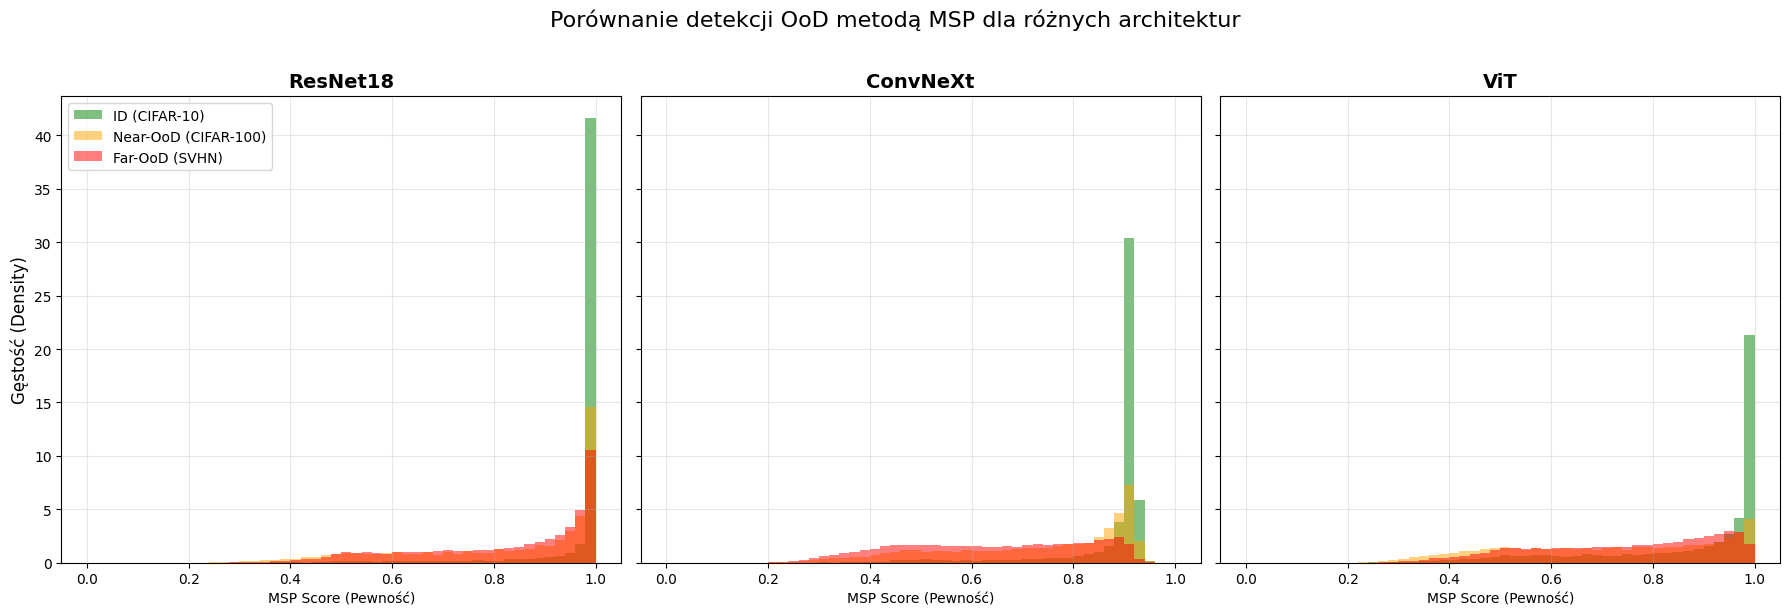

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

for i, (file_name, model, title) in enumerate(models_info):
    print(f"--- MSP dla {title} ---")

    print(f" - Liczę dla CIFAR-10 (ID)...")
    msp_id = get_msp_scores(model, loader_id, device)
    print(f" - Liczę dla CIFAR-100 (Near-OoD)...")
    msp_near = get_msp_scores(model, loader_near, device)
    print(f" - Liczę dla SVHN (Far-OoD)...")
    msp_far = get_msp_scores(model, loader_far, device)

    save_path = os.path.join(project_directory, f"{file_name}_msp_scores.npy")
    np.save(save_path, {
        "id": msp_id,
        "near": msp_near,
        "far": msp_far
    })
    print(f"Zapisano wyniki w: {save_path}\n")
    plot_msp(axes[i], msp_id, msp_near, msp_far, title)

axes[0].set_ylabel("Gęstość (Density)", fontsize=12)
axes[0].legend(loc='upper left')
fig.suptitle("Porównanie detekcji OoD metodą MSP dla różnych architektur", fontsize=16, y=1.02)
plt.tight_layout()

plot_path = os.path.join(project_directory, "porownanie_msp_3_modele.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\Wykres zbiorczy zapisano jako: {plot_path}")

plt.show()

# Porównanie Energy score  (ID vs near-OOD vs far-OOD)

In [ ]:
def plot_energy(ax, scores_id, scores_near, scores_far, title):
    all_scores = np.concatenate([scores_id, scores_near, scores_far])
    min_val, max_val = all_scores.min(), all_scores.max()

    bins = 50
    alpha = 0.5
    ax.hist(scores_id, bins=bins, range=(min_val, max_val), alpha=alpha, label='ID', color='green', density=True)
    ax.hist(scores_near, bins=bins, range=(min_val, max_val), alpha=alpha, label='Near-OoD', color='orange', density=True)
    ax.hist(scores_far, bins=bins, range=(min_val, max_val), alpha=alpha, label='Far-OoD', color='red', density=True)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Energy Score")
    ax.grid(True, alpha=0.3)

--- Energy score (T=1.0) dla ResNet18 ---
 - Liczę ID...
 - Liczę Near-OoD...
 - Liczę Far-OoD...
Zapisano wyniki w: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/resnet_energy_scores_T1.0.npy
--- Energy score (T=1.0) dla ConvNeXt ---
 - Liczę ID...
 - Liczę Near-OoD...
 - Liczę Far-OoD...
Zapisano wyniki w: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/convnext_energy_scores_T1.0.npy
--- Energy score (T=1.0) dla ViT ---
 - Liczę ID...
 - Liczę Near-OoD...
 - Liczę Far-OoD...
Zapisano wyniki w: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/vit_energy_scores_T1.0.npy
Wykres zapisano jako: porownanie_energy_T1.0_3_modele.png


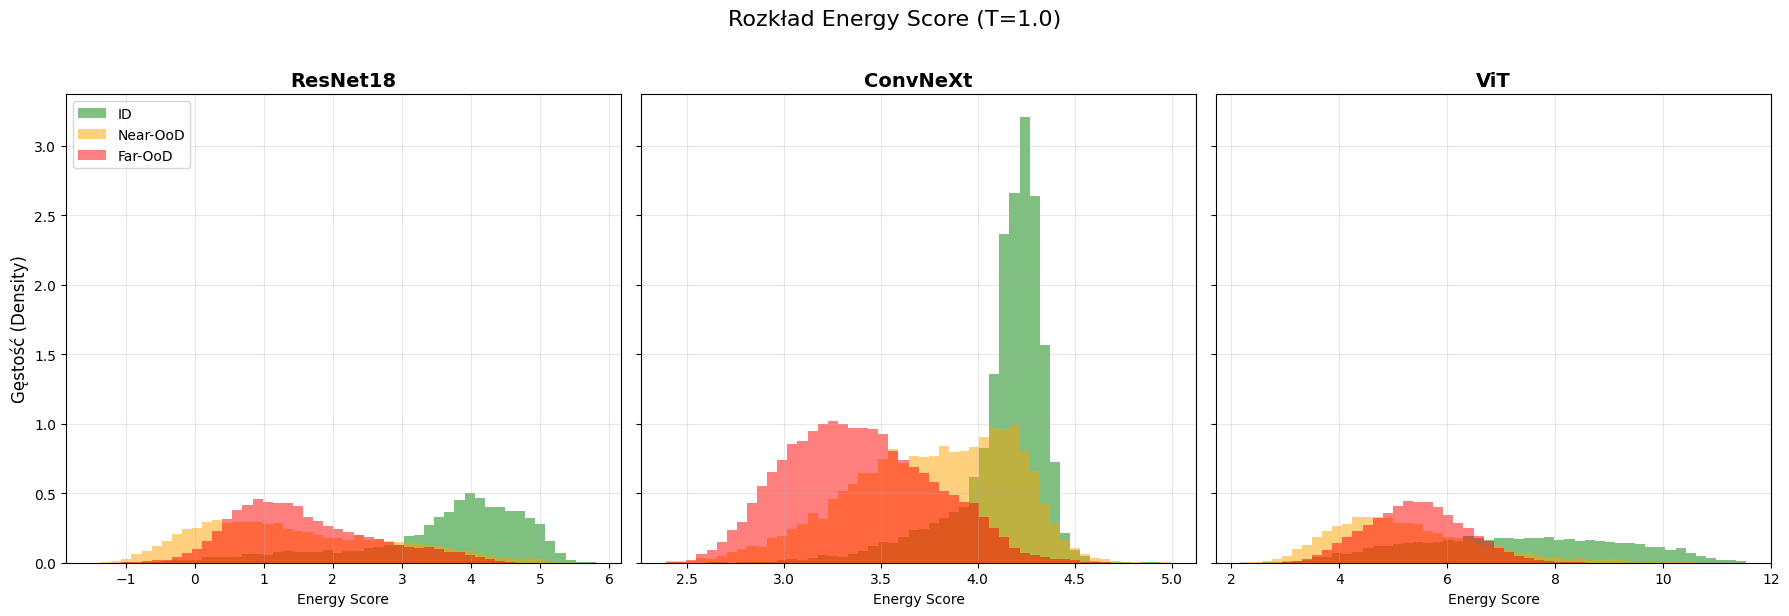

In [ ]:
T_param = 1.0

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (file_name, model, title) in enumerate(models_info):
    print(f"--- Energy score (T={T_param}) dla {title} ---")

    print(f" - Liczę ID...")
    energy_id = get_energy_scores(model, loader_id, device, T=T_param)
    print(f" - Liczę Near-OoD...")
    energy_near = get_energy_scores(model, loader_near, device, T=T_param)
    print(f" - Liczę Far-OoD...")
    energy_far = get_energy_scores(model, loader_far, device, T=T_param)

    save_path = os.path.join(project_directory, f"{file_name}_energy_scores_T{T_param}.npy")
    np.save(save_path, {
        "id": energy_id,
        "near": energy_near,
        "far": energy_far
    })
    print(f"Zapisano wyniki w: {save_path}")

    plot_energy(axes[i], energy_id, energy_near, energy_far, title)

axes[0].set_ylabel("Gęstość (Density)", fontsize=12)
axes[0].legend(loc='upper left')
fig.suptitle(f"Rozkład Energy Score (T={T_param})", fontsize=16, y=1.02) # wyższe = większa pewność
plt.tight_layout()

img_name = f"porownanie_energy_T{T_param}_3_modele.png"
plt.savefig(os.path.join(project_directory, img_name), dpi=300, bbox_inches='tight')
print(f"Wykres zapisano jako: {img_name}")
plt.show()

# Porównanie ODIN  (ID vs near-OOD vs far-OOD)

In [ ]:
def plot_odin(ax, scores_id, scores_near, scores_far, title):
    all_scores = np.concatenate([scores_id, scores_near, scores_far])
    min_val, max_val = all_scores.min(), all_scores.max()

    bins = 50
    alpha = 0.6

    ax.hist(scores_id, bins=bins, range=(min_val, max_val), alpha=alpha, label='ID', color='green', density=True)
    ax.hist(scores_near, bins=bins, range=(min_val, max_val), alpha=alpha, label='Near-OoD', color='orange', density=True)
    ax.hist(scores_far, bins=bins, range=(min_val, max_val), alpha=alpha, label='Far-OoD', color='red', density=True)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("ODIN Score (Pewność)")
    ax.grid(True, alpha=0.3)

--- ODIN (T=1000.0, eps=0.0014 dla: ResNet18 ---
 - Liczę ID...
 - Liczę Near-OoD...
 - Liczę Far-OoD...
Zapisano wyniki w: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/resnet_T=1000.0_eps=0.0014_odin_scores.npy

--- ODIN (T=1000.0, eps=0.0014 dla: ConvNeXt ---
 - Liczę ID...
 - Liczę Near-OoD...
 - Liczę Far-OoD...
Zapisano wyniki w: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/convnext_T=1000.0_eps=0.0014_odin_scores.npy

--- ODIN (T=1000.0, eps=0.0014 dla: ViT ---
 - Liczę ID...
 - Liczę Near-OoD...
 - Liczę Far-OoD...
Zapisano wyniki w: /content/drive/MyDrive/TAI/sem2/SN/ood/251217_ood/vit_T=1000.0_eps=0.0014_odin_scores.npy

Wykres zapisano jako: porownanie_odin_T=1000.0_eps=0.0014_3_modele.png


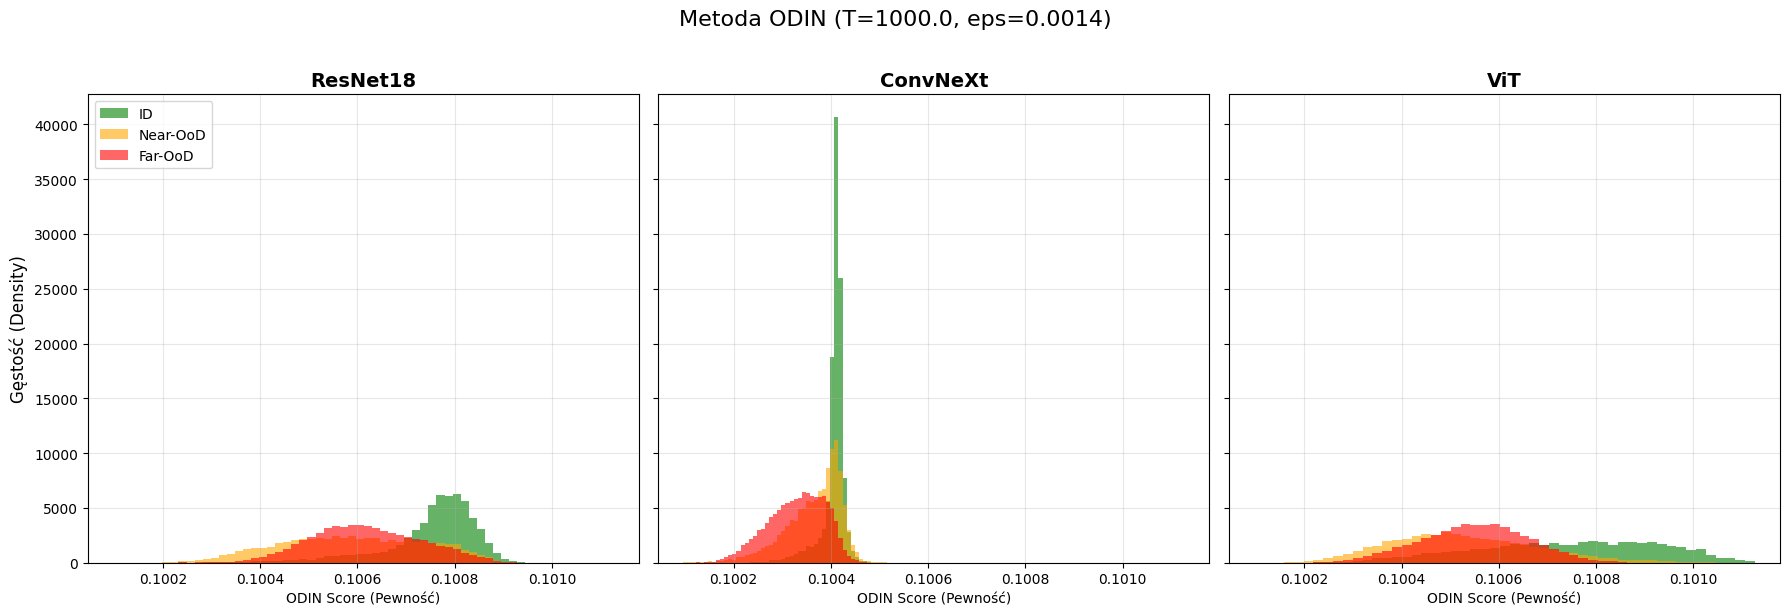

In [ ]:
ODIN_T = 1000.0
ODIN_EPS = 0.0014

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

for i, (file_name, model, title) in enumerate(models_info):
    print(f"--- ODIN (T={ODIN_T}, eps={ODIN_EPS} dla: {title} ---")

    print(f" - Liczę ID...")
    odin_id = get_odin_scores(model, loader_id, device, T=ODIN_T, epsilon=ODIN_EPS)
    print(f" - Liczę Near-OoD...")
    odin_near = get_odin_scores(model, loader_near, device, T=ODIN_T, epsilon=ODIN_EPS)
    print(f" - Liczę Far-OoD...")
    odin_far = get_odin_scores(model, loader_far, device, T=ODIN_T, epsilon=ODIN_EPS)

    save_path = os.path.join(project_directory, f"{file_name}_T={ODIN_T}_eps={ODIN_EPS}_odin_scores.npy")
    np.save(save_path, {
        "id": odin_id,
        "near": odin_near,
        "far": odin_far
    })
    print(f"Zapisano wyniki w: {save_path}")

    plot_odin(axes[i], odin_id, odin_near, odin_far, title)
    print("")

axes[0].set_ylabel("Gęstość (Density)", fontsize=12)
axes[0].legend(loc='upper left')
fig.suptitle(f"Metoda ODIN (T={ODIN_T}, eps={ODIN_EPS})", fontsize=16, y=1.02)
plt.tight_layout()

img_name = f"porownanie_odin_T={ODIN_T}_eps={ODIN_EPS}_3_modele.png"
plt.savefig(os.path.join(project_directory, img_name), dpi=300, bbox_inches='tight')
print(f"Wykres zapisano jako: {img_name}")
plt.show()

# Porównanie Mahalanobis (ID vs near-OOD vs far-OOD)

In [ ]:
def plot_mahalanobis(ax, scores_id, scores_near, scores_far, title):
    all_scores = np.concatenate([scores_id, scores_near, scores_far])
    min_val, max_val = all_scores.min(), all_scores.max()

    bins = 50
    alpha = 0.5
    ax.hist(scores_id, bins=bins, range=(min_val, max_val), alpha=alpha, label='ID', color='green', density=True)
    ax.hist(scores_near, bins=bins, range=(min_val, max_val), alpha=alpha, label='Near-OoD', color='orange', density=True)
    ax.hist(scores_far, bins=bins, range=(min_val, max_val), alpha=alpha, label='Far-OoD', color='red', density=True)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Mahalanobis Distance (wyższy = ID)")
    ax.grid(True, alpha=0.3)

--- Obliczanie statystyk Mahalanobisa dla ResNet18 ---
 - Liczę ID (CIFAR-10)...
 - Liczę Near-OoD (CIFAR-100)...
 - Liczę Far-OoD (SVHN)...
--- Obliczanie statystyk Mahalanobisa dla ConvNeXt ---
 - Liczę ID (CIFAR-10)...
 - Liczę Near-OoD (CIFAR-100)...
 - Liczę Far-OoD (SVHN)...
--- Obliczanie statystyk Mahalanobisa dla ViT ---
 - Liczę ID (CIFAR-10)...
 - Liczę Near-OoD (CIFAR-100)...
 - Liczę Far-OoD (SVHN)...


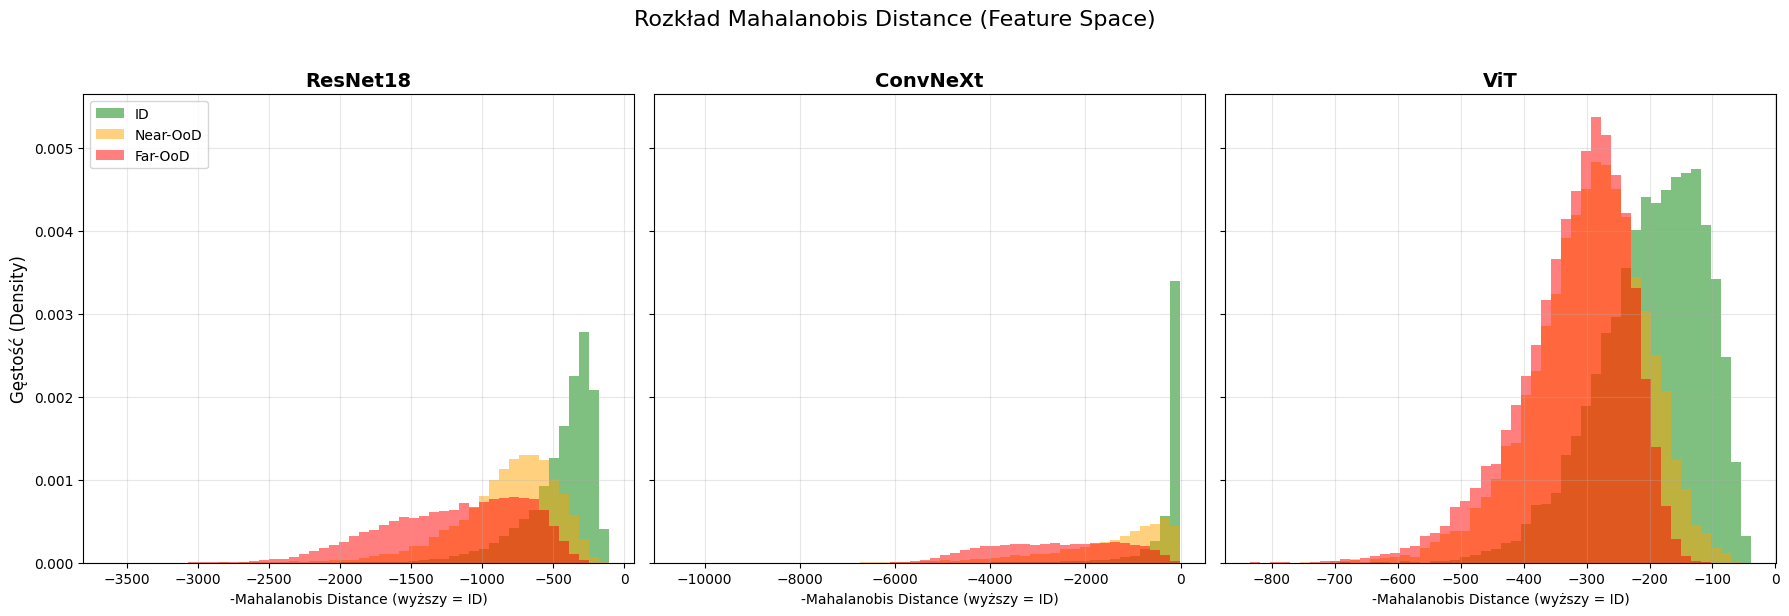

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (file_name, model, title) in enumerate(models_info):
    print(f"--- Obliczanie statystyk Mahalanobisa dla {title} ---")

    # parametry rozkładu na danych treningowych
    means, precision = get_mahalanobis_stats(model, loader_train_id, device)

    print(f" - Liczę ID (CIFAR-10)...")
    m_id = get_mahalanobis_scores(model, loader_id, device, means, precision)
    print(f" - Liczę Near-OoD (CIFAR-100)...")
    m_near = get_mahalanobis_scores(model, loader_near, device, means, precision)
    print(f" - Liczę Far-OoD (SVHN)...")
    m_far = get_mahalanobis_scores(model, loader_far, device, means, precision)

    save_path = os.path.join(project_directory, f"{file_name}_mahalanobis_scores.npy")
    np.save(save_path, {"id": m_id, "near": m_near, "far": m_far})

    plot_mahalanobis(axes[i], m_id, m_near, m_far, title)

axes[0].set_ylabel("Gęstość (Density)", fontsize=12)
axes[0].legend(loc='upper left')
fig.suptitle("Rozkład Mahalanobis Distance (Feature Space)", fontsize=16, y=1.02)
plt.tight_layout()

img_name = "porownanie_mahalanobis_3_modele.png"
plt.savefig(os.path.join(project_directory, img_name), dpi=300, bbox_inches='tight')
plt.show()

# Porównanie metod dla każdej z archtektur
przygotowano:
- porównanie na historgramach ID vs near-OOD
- wykres ROC dla near-OOD
- wykresy pudełkowe (boxploty) ID vs near-OOD vs far-OOD

- wyznaczenie AUROC, FPR@95

### Uzasadnienie doboru metryk:
- *Histogramy*: Pozwalają wzrokowo ocenić, w jakim stopniu rozkłady pewności dla danych znanych (ID) i obcych (OoD) nakładają się na siebie, co pokazuje trudność ich rozdzielenia.

- *Krzywa ROC*: Obrazuje zdolność modelu do odróżniania klas przy różnych progach decyzyjnych, pokazując zależność między trafnością wykrywania OoD a liczbą fałszywych alarmów.

- *Boxploty*: Pozwalają błyskawicznie porównać mediany i stabilność (rozrzut) wyników dla wielu zbiorów danych (ID, Near-OoD, Far-OoD).

- *AUROC*: Sprowadza całą krzywą ROC do jednej liczby, która mówi, jakie jest prawdopodobieństwo, że model oceni losową próbkę ID jako "bardziej pewną" niż próbkę OoD.

- *FPR@95* (False Positive Rate at 95% True Positive Rate) mówi, jaki odsetek danych obcych (OoD) zostanie błędnie zaakceptowany przez system, gdy ustalimy próg tak, aby poprawnie rozpoznawał 95% danych znanych (ID).


In [ ]:
def calculate_scores(model, loader, method, T=1.0, noise_magnitude=0.0):
    if method == 'msp':
        return get_msp_scores(model, loader, device)
    elif method == 'energy':
        return get_energy_scores(model, loader, device, T=T)
    elif method == 'odin':
        return get_odin_scores(model, loader, device, T=T, epsilon=noise_magnitude)

In [ ]:
def calc_fpr_at_95_tpr(id_scores, ood_scores):
    # 1 = ID, 0 = OOD
    y_true = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])
    y_scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    # Znajdź FPR dla TPR >= 0.95
    target_tpr = 0.95
    if np.max(tpr) < target_tpr:
        return 1.0 # Najgorszy przypadek

    idx = np.searchsorted(tpr, target_tpr)
    return fpr[idx]


ANALIZA MODELU: ResNet18
Przygotowanie statystyk dla Mahalanobisa (Train ID)...
--> Metoda: MSP


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


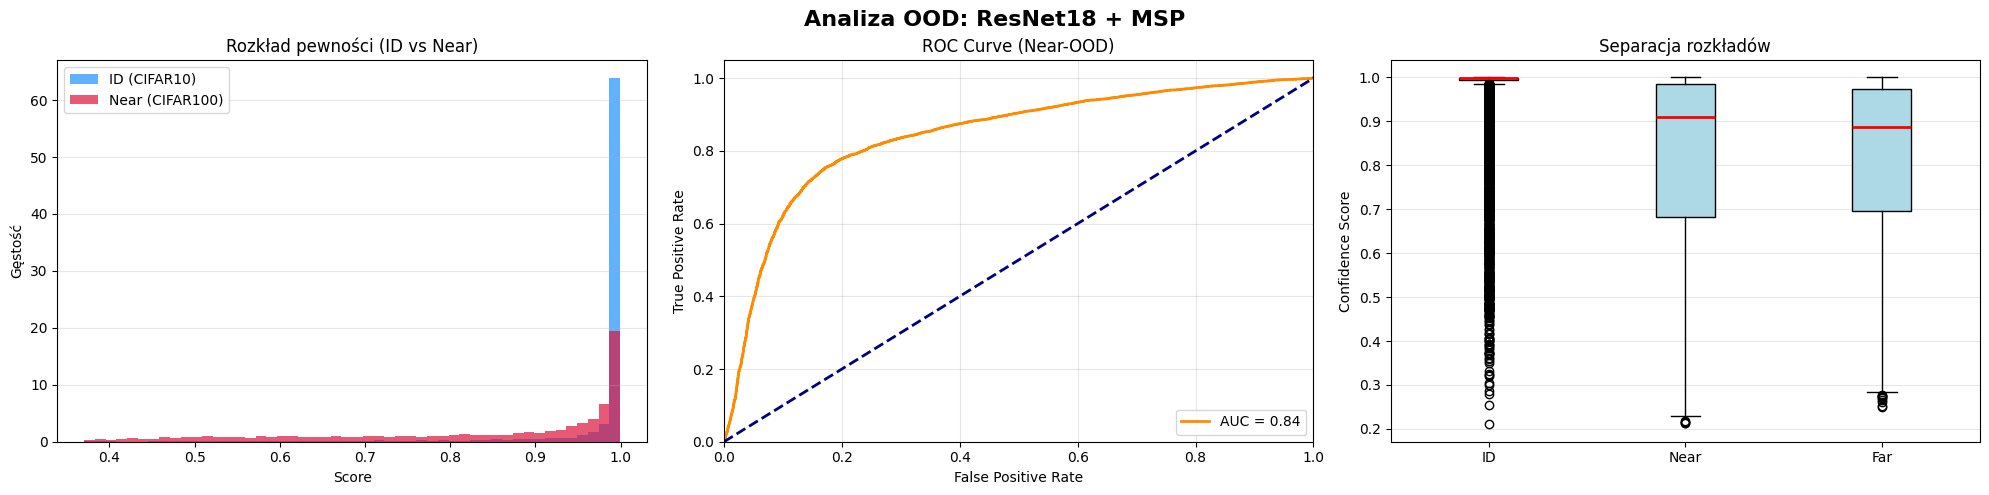

--> Metoda: Energy


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


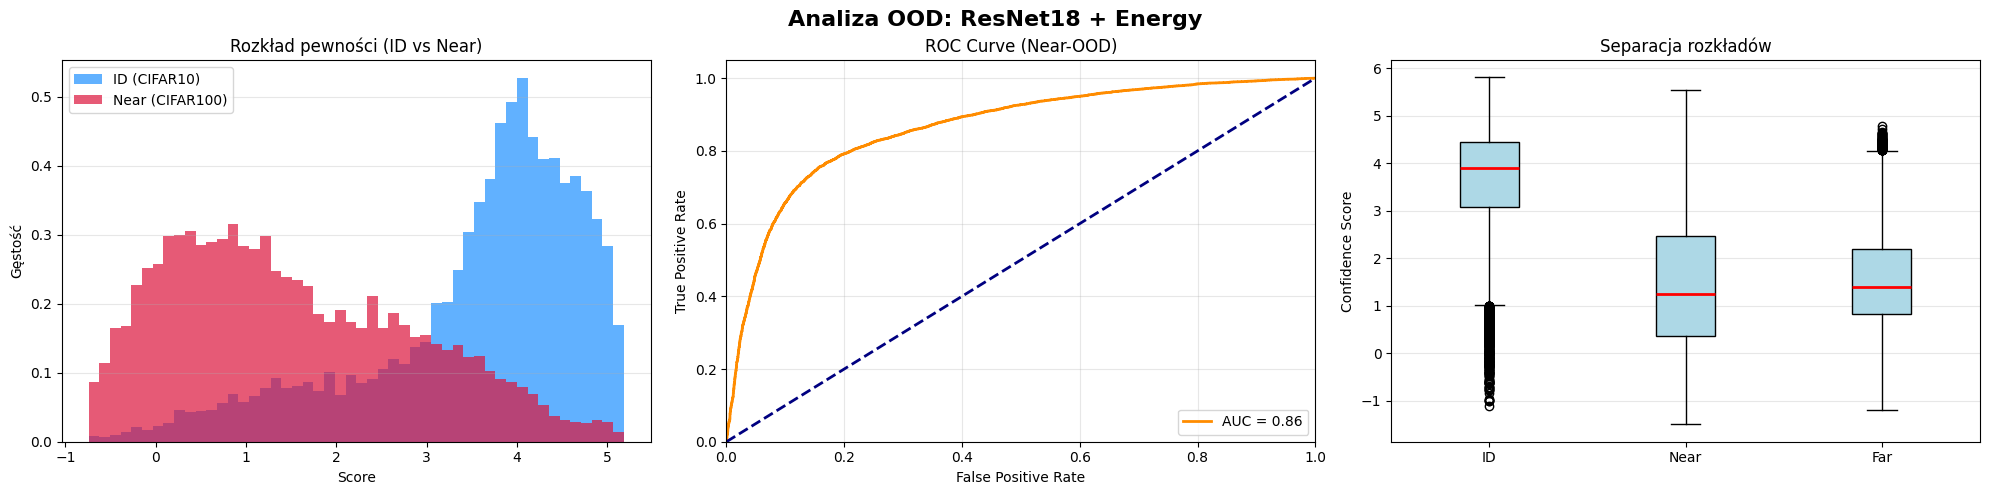

--> Metoda: ODIN


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


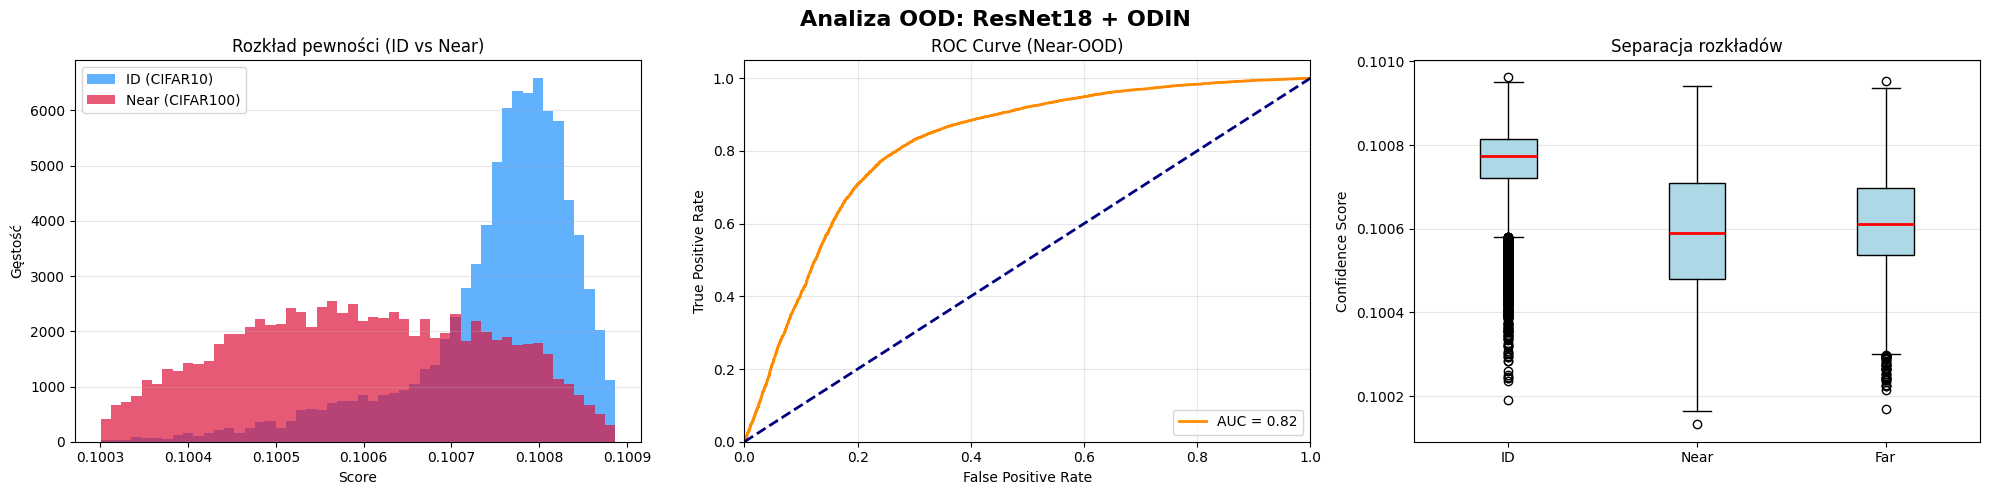

--> Metoda: Mahalanobis


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


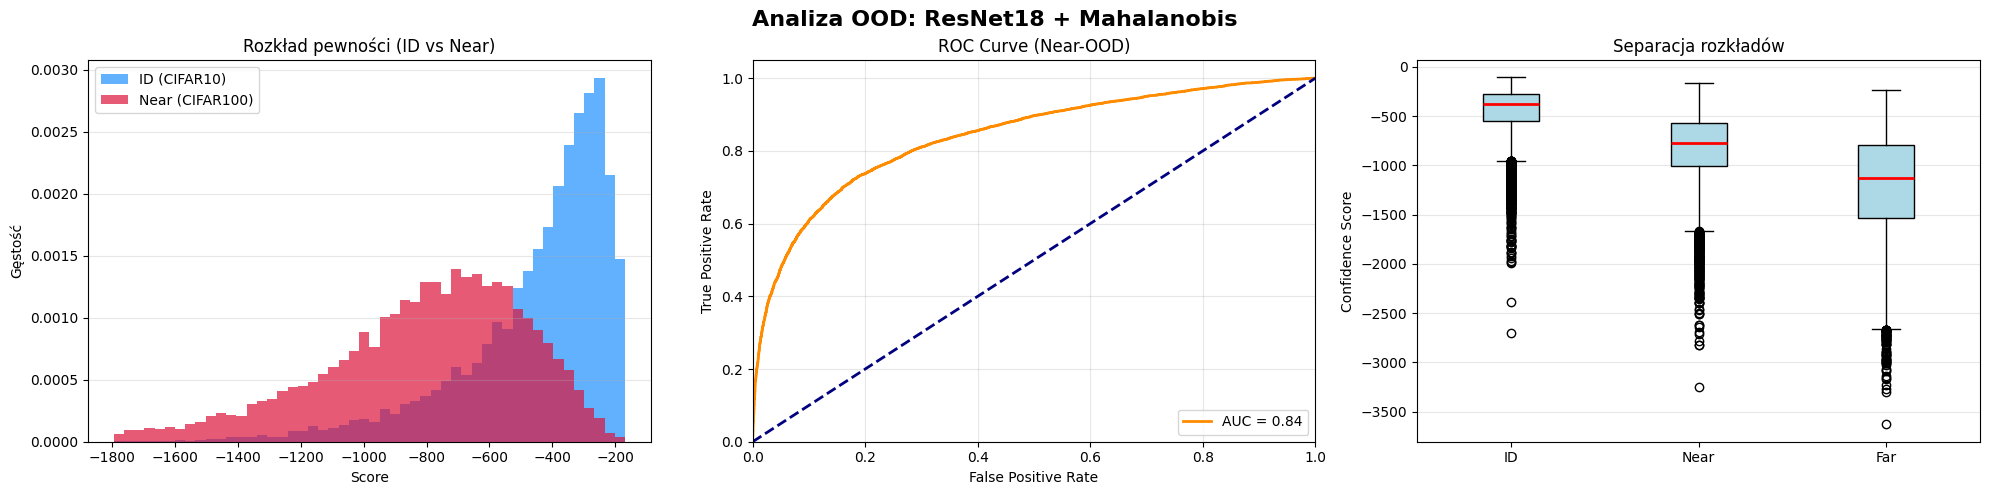


ANALIZA MODELU: ConvNeXt
Przygotowanie statystyk dla Mahalanobisa (Train ID)...
--> Metoda: MSP


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


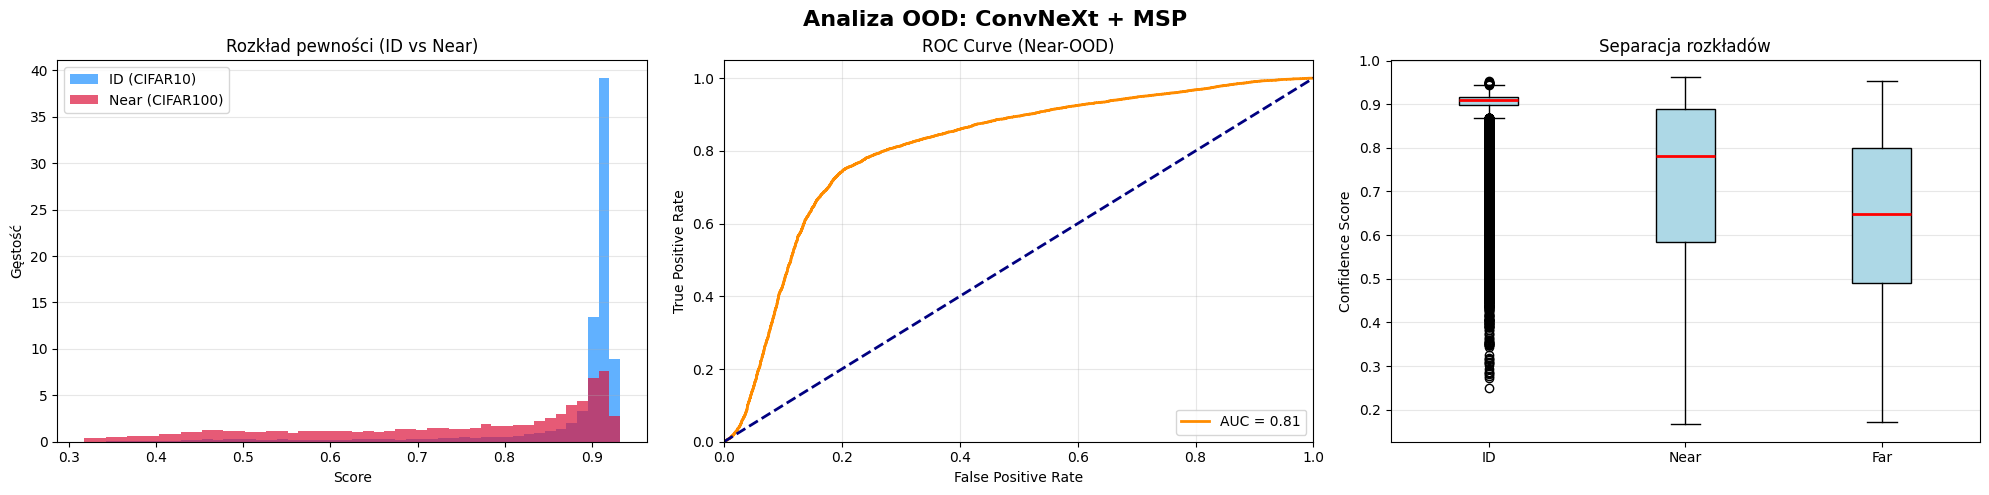

--> Metoda: Energy


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


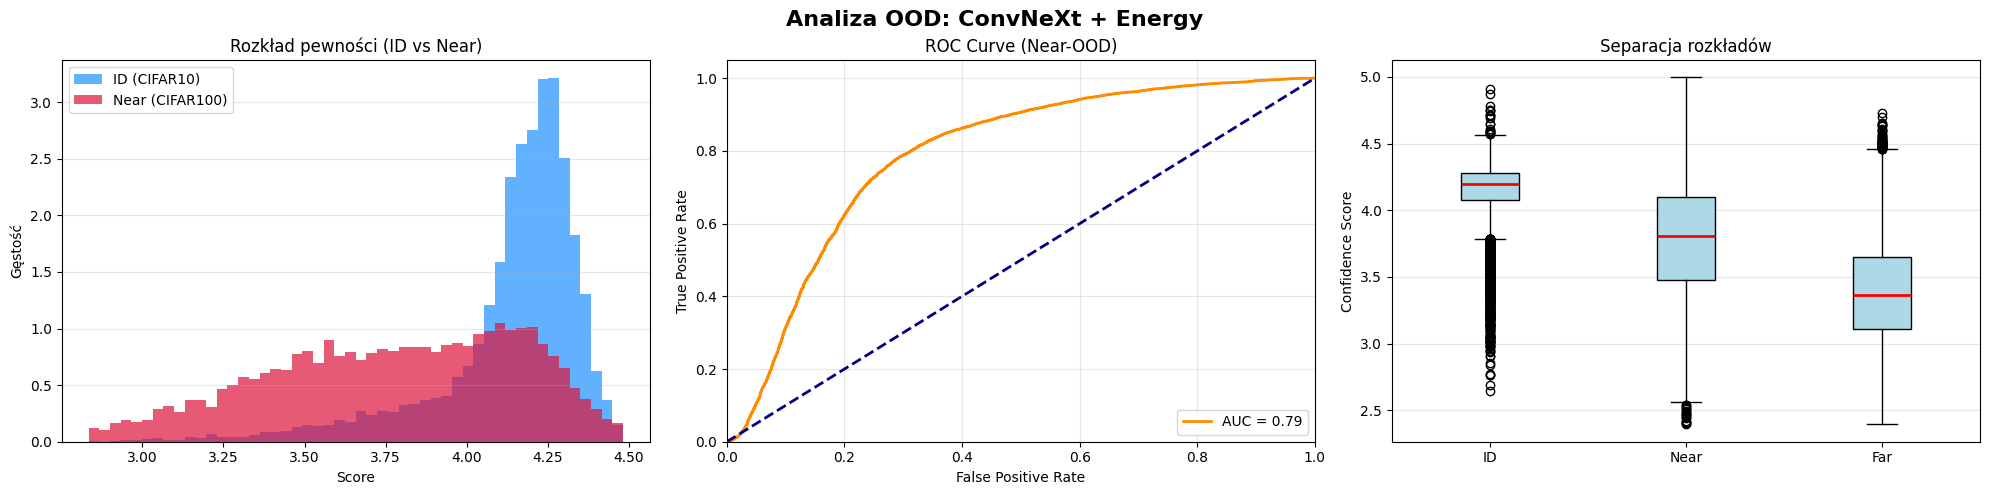

--> Metoda: ODIN


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


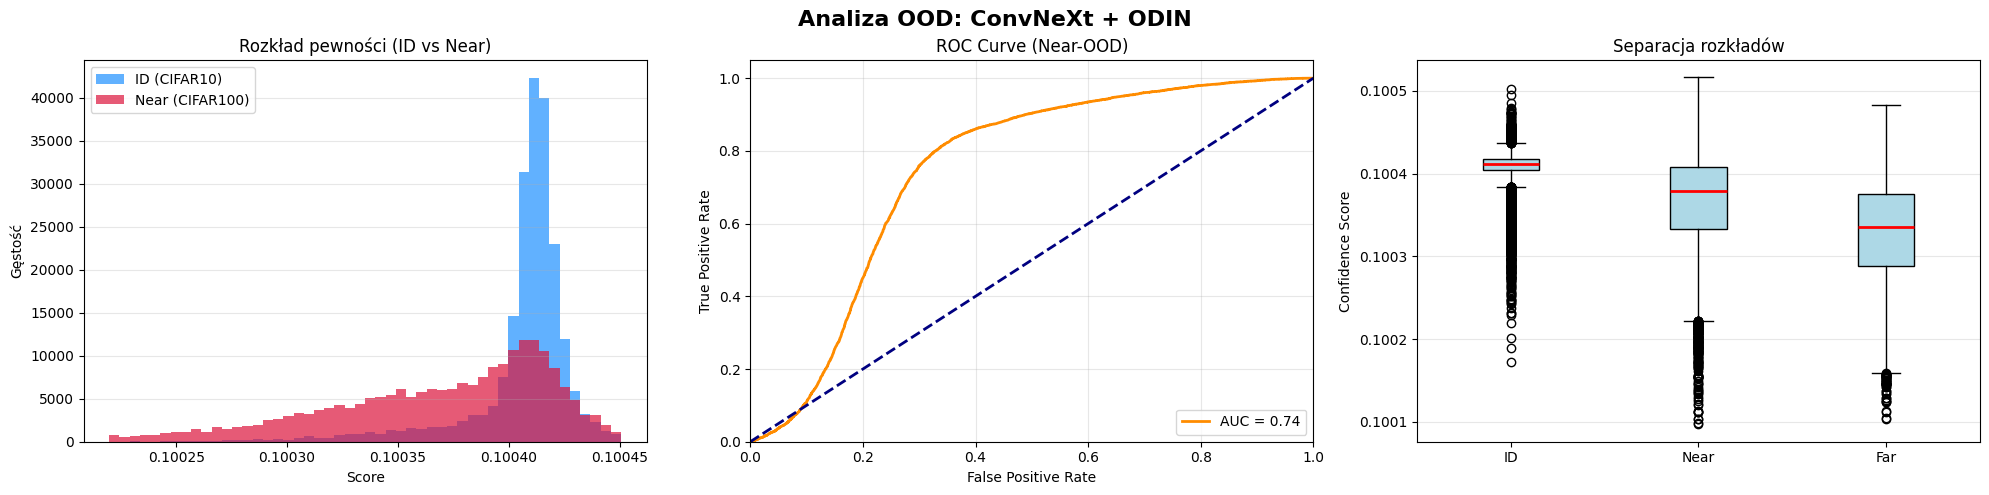

--> Metoda: Mahalanobis


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


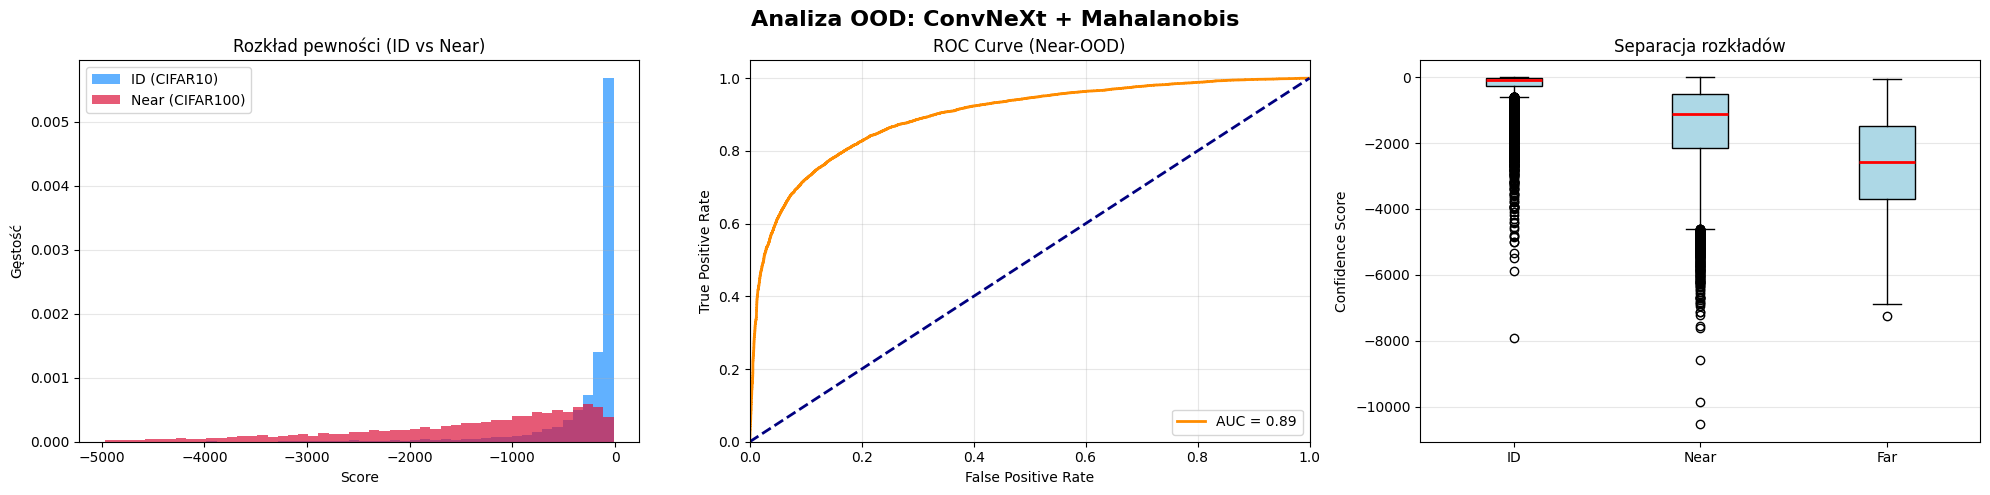


ANALIZA MODELU: ViT
Przygotowanie statystyk dla Mahalanobisa (Train ID)...
--> Metoda: MSP


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


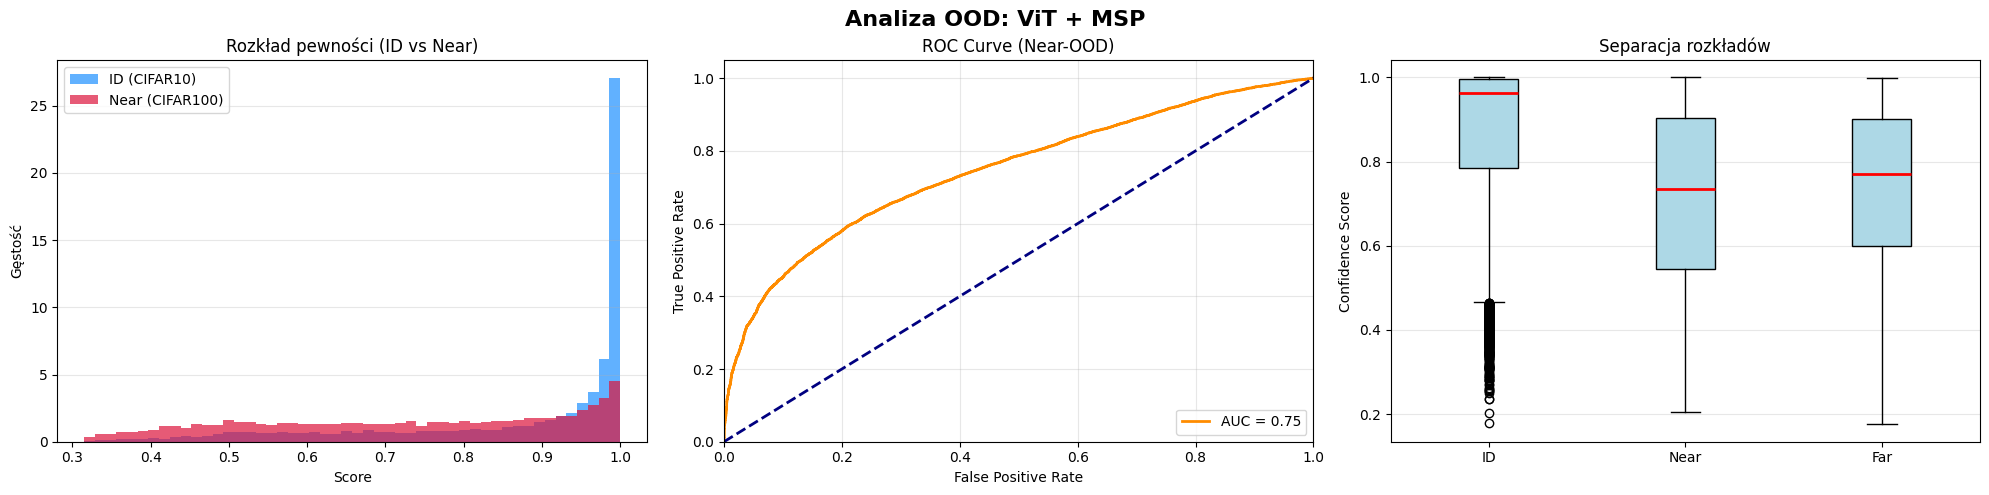

--> Metoda: Energy


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


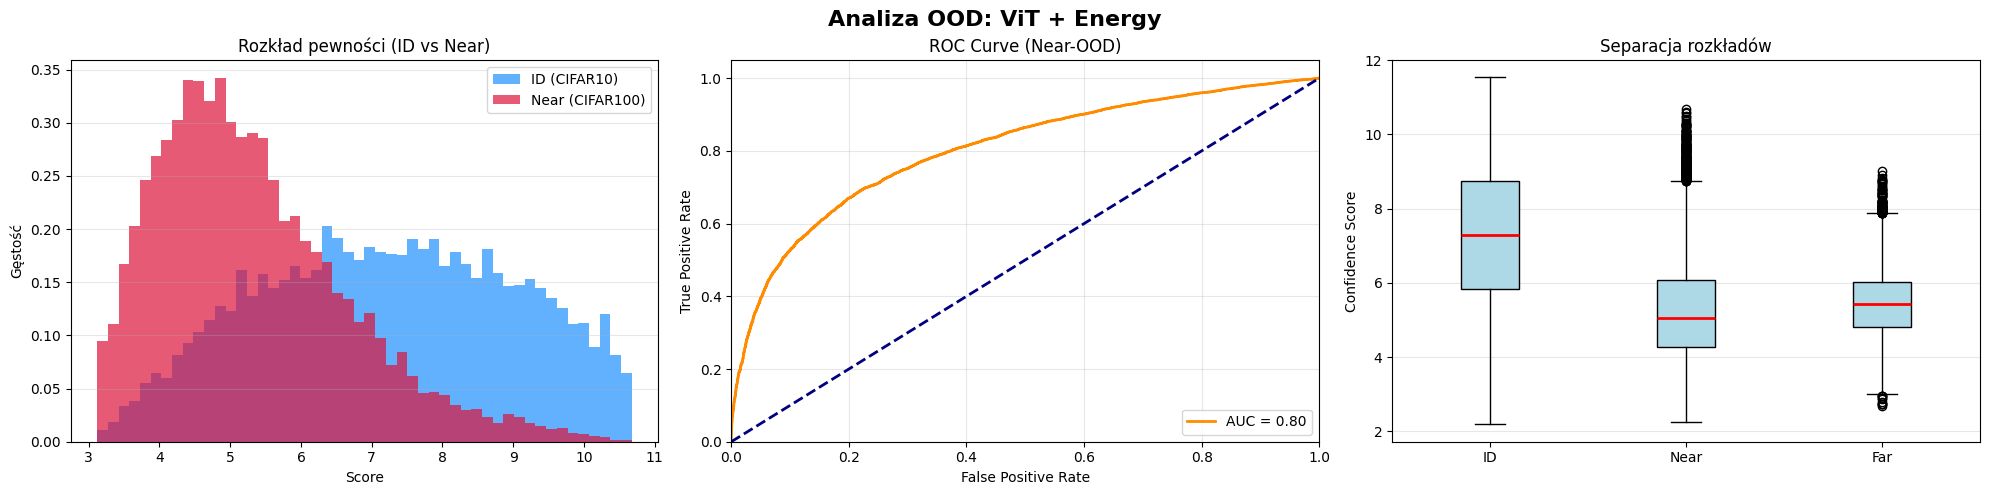

--> Metoda: ODIN


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


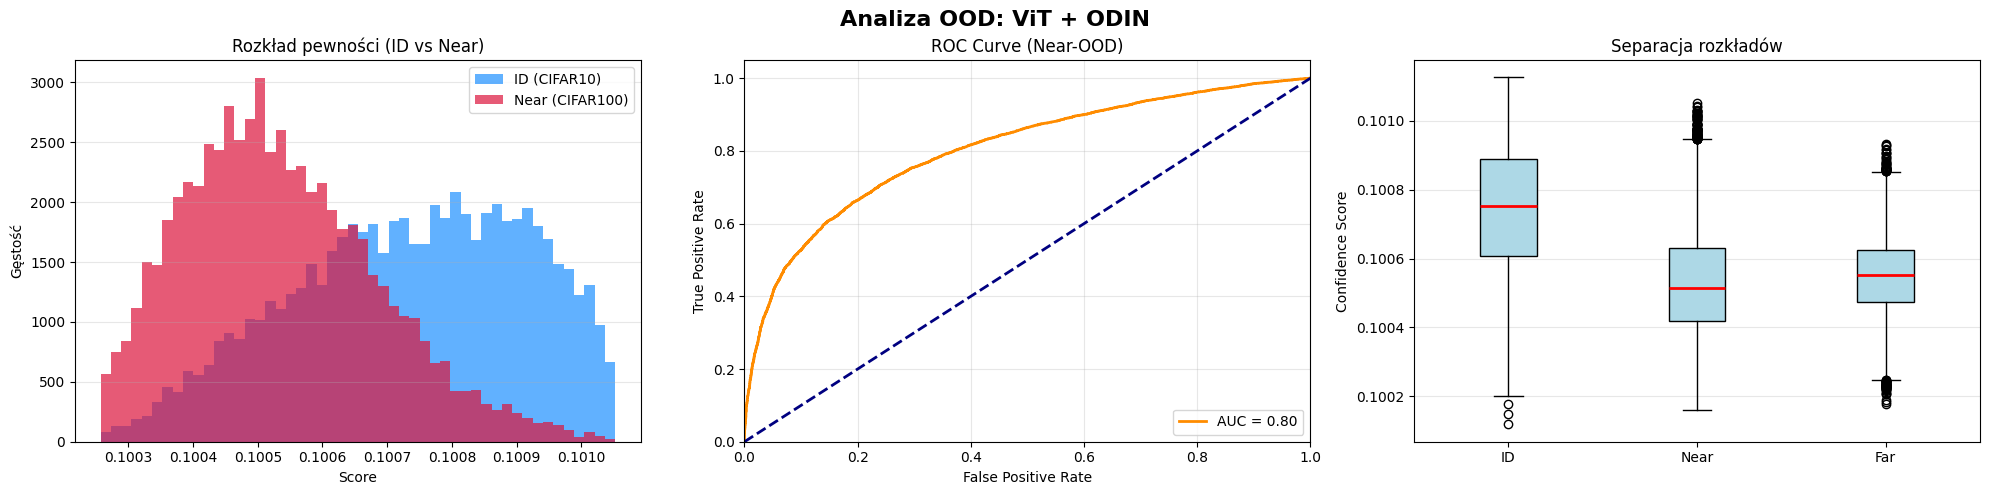

--> Metoda: Mahalanobis


/tmp/ipython-input-680580619.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])


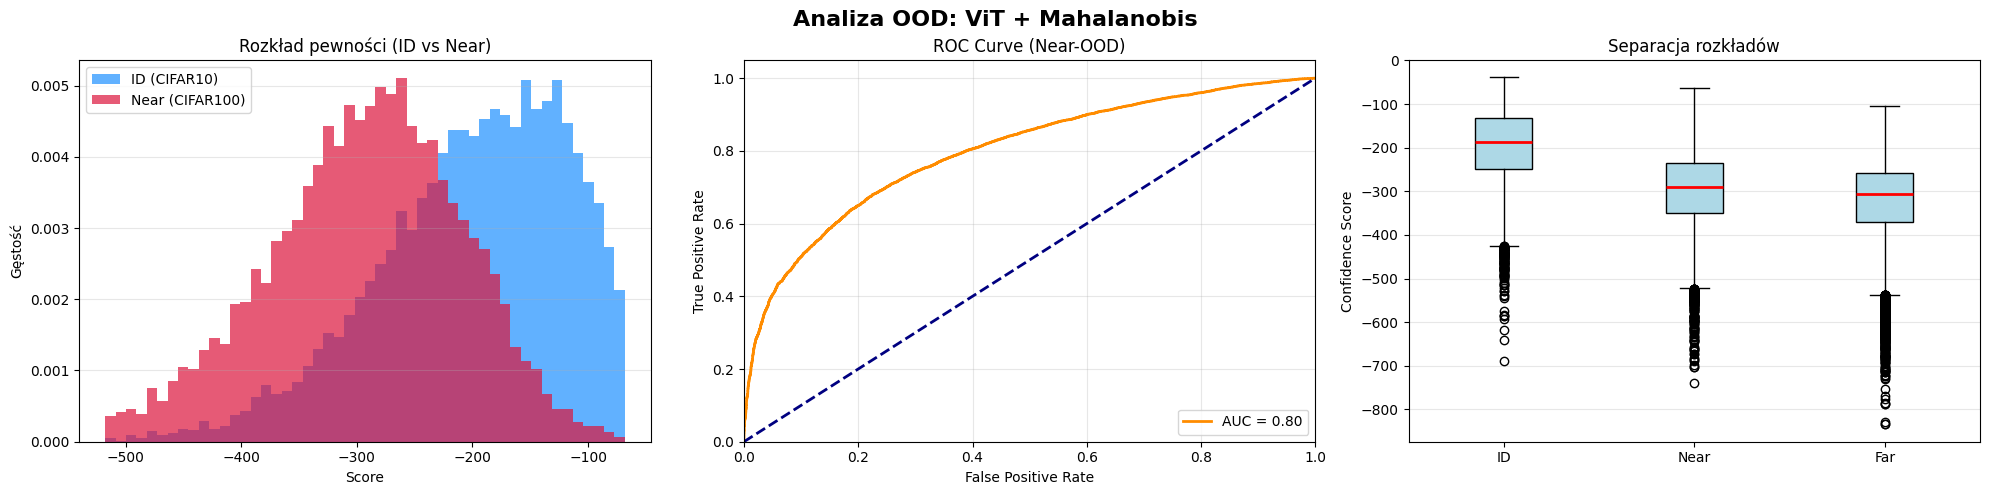


=== PODSUMOWANIE WYNIKÓW ===
   Architektura       Metoda  Near (C100) AUROC  Near (C100) FPR@95  \
0      ResNet18          MSP             0.8427              0.6775   
1      ResNet18       Energy             0.8625              0.5994   
2      ResNet18         ODIN             0.8183              0.6062   
3      ResNet18  Mahalanobis             0.8396              0.6996   
4      ConvNeXt          MSP             0.8077              0.7084   
5      ConvNeXt       Energy             0.7872              0.6320   
6      ConvNeXt         ODIN             0.7448              0.6582   
7      ConvNeXt  Mahalanobis             0.8944              0.5201   
8           ViT          MSP             0.7463              0.8269   
9           ViT       Energy             0.8015              0.7611   
10          ViT         ODIN             0.8030              0.7583   
11          ViT  Mahalanobis             0.7967              0.7581   

    Far (SVHN) AUROC  Far (SVHN) FPR@95  
0   

In [ ]:
models_to_test = {
   "ResNet18": model_resnet,
   "ConvNeXt": model_convnext,
   "ViT": model_vit
}

methods = [
    {'name': 'MSP', 'type': 'msp', 'T': 1.0, 'eps': 0.0},
    {'name': 'Energy', 'type': 'energy', 'T': 1.0, 'eps': 0.0},
    {'name': 'ODIN', 'type': 'odin', 'T': 1000.0, 'eps': 0.0014},
    {'name': 'Mahalanobis', 'type': 'mahalanobis'}
]

results_list = []

plots_dir = os.path.join(project_directory, "plots")
os.makedirs(plots_dir, exist_ok=True)

for model_name, model in models_to_test.items():
    print(f"\n{'='*40}")
    print(f"ANALIZA MODELU: {model_name}")
    print(f"{'='*40}")

    # Obliczamy statystyki raz dla danego modelu przed wejściem w pętlę metod
    print("Przygotowanie statystyk dla Mahalanobisa (Train ID)...")
    m_means, m_precision = get_mahalanobis_stats(model, loader_train_id, device)

    for m in methods:
        print(f"--> Metoda: {m['name']}")

        if m['type'] == 'mahalanobis':
            id_scores = get_mahalanobis_scores(model, loader_id, device, m_means, m_precision)
            near_scores = get_mahalanobis_scores(model, loader_near, device, m_means, m_precision)
            far_scores = get_mahalanobis_scores(model, loader_far, device, m_means, m_precision)
        else:
            id_scores = calculate_scores(model, loader_id, method=m['type'], T=m['T'], noise_magnitude=m['eps'])
            near_scores = calculate_scores(model, loader_near, method=m['type'], T=m['T'], noise_magnitude=m['eps'])
            far_scores = calculate_scores(model, loader_far, method=m['type'], T=m['T'], noise_magnitude=m['eps'])

        # --- OBLICZENIA METRYK ---
        # Near-OOD
        y_true_near = np.concatenate([np.ones(len(id_scores)), np.zeros(len(near_scores))])
        y_scores_near = np.concatenate([id_scores, near_scores])
        auroc_near = roc_auc_score(y_true_near, y_scores_near)
        fpr_near = calc_fpr_at_95_tpr(id_scores, near_scores)

        # Far-OOD
        y_true_far = np.concatenate([np.ones(len(id_scores)), np.zeros(len(far_scores))])
        y_scores_far = np.concatenate([id_scores, far_scores])
        auroc_far = roc_auc_score(y_true_far, y_scores_far)
        fpr_far = calc_fpr_at_95_tpr(id_scores, far_scores)

        results_list.append({
            'Architektura': model_name,
            'Metoda': m['name'],
            'Near (C100) AUROC': auroc_near,
            'Near (C100) FPR@95': fpr_near,
            'Far (SVHN) AUROC': auroc_far,
            'Far (SVHN) FPR@95': fpr_far
        })

        # --- WIZUALIZACJA (Histogramy i Boxploty) ---
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        fig.suptitle(f"Analiza OOD: {model_name} + {m['name']}", fontsize=16, fontweight='bold')

        # A. Histogram (ID vs Near
        ax_hist = axes[0]
        ax_hist.set_title("Rozkład pewności (ID vs Near)", fontsize=12)
        #-----------------------------------------------
        # Używamy percentyli do skali, bo Mahalanobis ma inne zakresy niż Softmax
        all_s = np.concatenate([id_scores, near_scores])
        range_val = (np.percentile(all_s, 1), np.percentile(all_s, 99))

        ax_hist.hist(id_scores, bins=50, range=range_val, alpha=0.7, density=True, label='ID (CIFAR10)', color='dodgerblue')
        ax_hist.hist(near_scores, bins=50, range=range_val, alpha=0.7, density=True, label='Near (CIFAR100)', color='crimson')
        #----------------------------------------------------------
        # ax_hist.hist(id_scores, bins=50, alpha=0.7, density=True, label='ID (CIFAR10)', color='dodgerblue', edgecolor='black', linewidth=0.5)
        # ax_hist.hist(near_scores, bins=50, alpha=0.7, density=True, label='Near (CIFAR100)', color='crimson', edgecolor='black', linewidth=0.5)
        #---------------------------------------------------------
        ax_hist.set_xlabel('Score')
        ax_hist.set_ylabel('Gęstość')
        ax_hist.legend()
        ax_hist.grid(axis='y', alpha=0.3)

        # --- B. ROC CURVE (Near) ---
        ax_roc = axes[1]
        fpr_roc, tpr_roc, _ = roc_curve(y_true_near, y_scores_near)
        ax_roc.set_title(f"ROC Curve (Near-OOD)", fontsize=12)
        ax_roc.plot(fpr_roc, tpr_roc, color='darkorange', lw=2, label=f'AUC = {auroc_near:.2f}')
        ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.legend(loc="lower right")
        ax_roc.grid(alpha=0.3)

        # --- C. BOXPLOT (Separacja) ---
        ax_box = axes[2]
        ax_box.set_title("Separacja rozkładów", fontsize=12)
        data_to_plot = [id_scores, near_scores, far_scores]
        bp = ax_box.boxplot(data_to_plot, patch_artist=True, labels=['ID', 'Near', 'Far'])

        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
        for median in bp['medians']:
            median.set(color='red', linewidth=2)

        ax_box.set_ylabel('Confidence Score')
        ax_box.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.subplots_adjust(top=0.88)
        plt.savefig(os.path.join(plots_dir, f"Combined_{model_name}_{m['name']}.png"), dpi=100)
        plt.show()

df_results = pd.DataFrame(results_list)

print("\n=== PODSUMOWANIE WYNIKÓW ===")
pd.options.display.float_format = '{:,.4f}'.format
print(df_results)

# Wizualizacje przestrzeni cech

[1/3] Przetwarzanie modelu: ResNet18...
 -> Liczę UMAP dla ResNet18...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 -> Liczę PCA dla ResNet18...
[2/3] Przetwarzanie modelu: ConvNeXt...
 -> Liczę UMAP dla ConvNeXt...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 -> Liczę PCA dla ConvNeXt...
[3/3] Przetwarzanie modelu: ViT...
 -> Liczę UMAP dla ViT...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 -> Liczę PCA dla ViT...


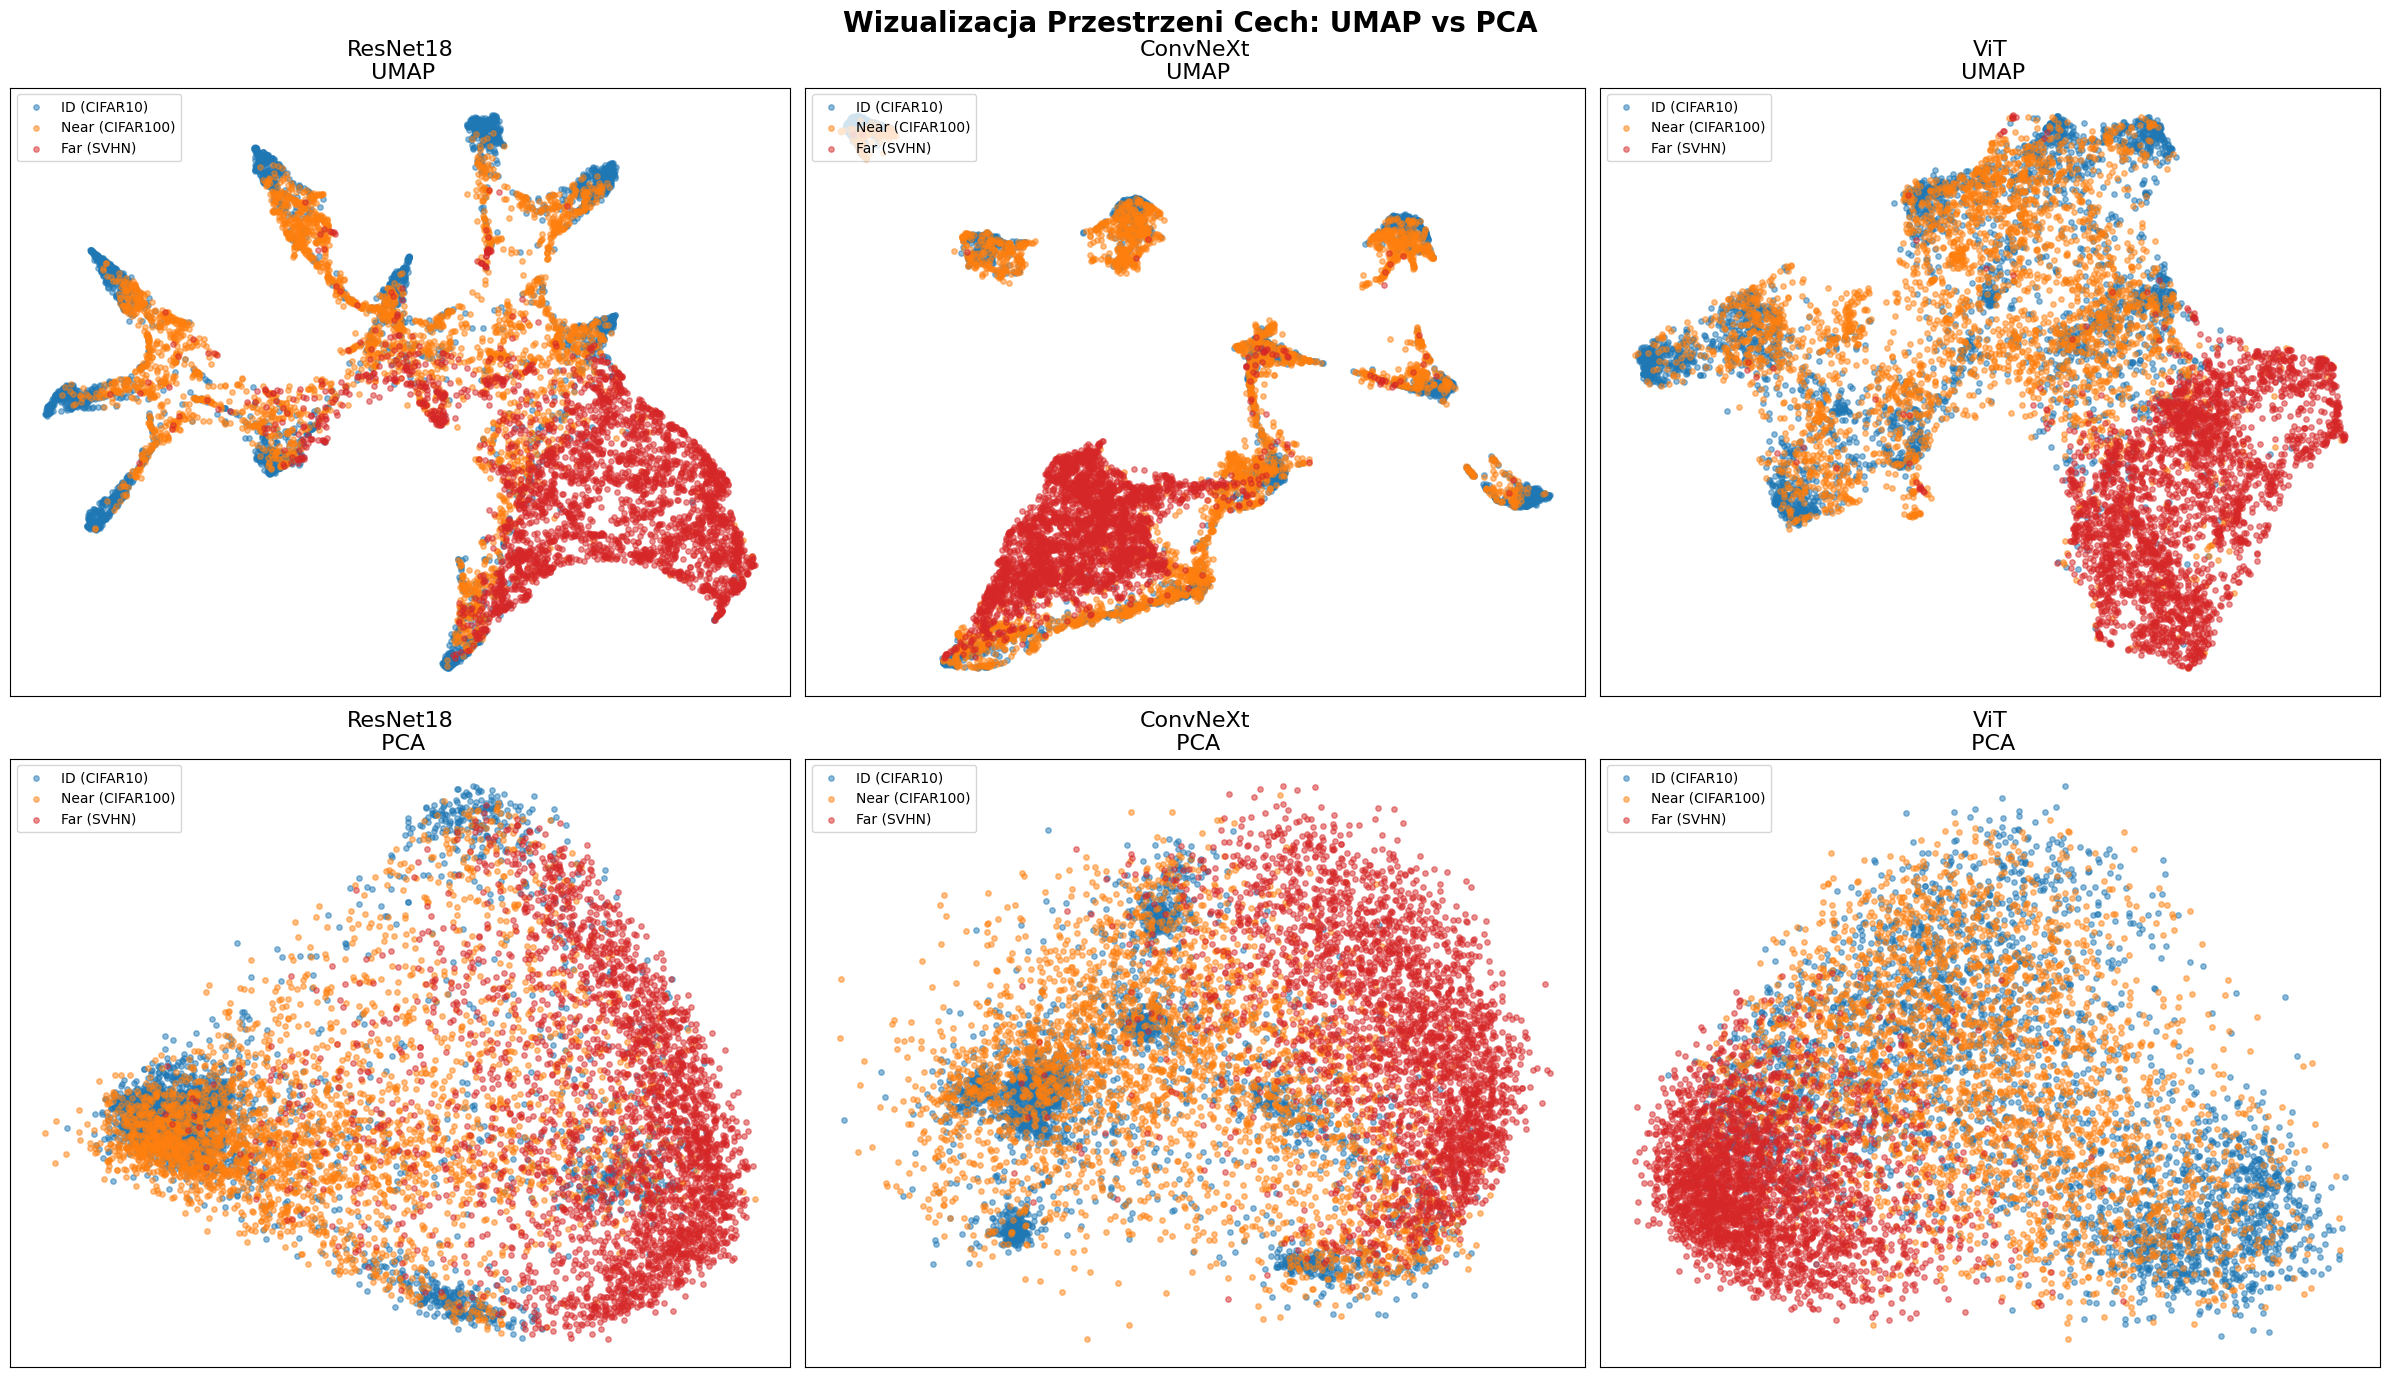

In [ ]:
def get_embeddings(model, loader, device, limit=500):
    model.eval()
    feats = []

    with torch.no_grad():
      for i,(img, _) in enumerate(loader):
        _, f = model(img.to(device), return_features=True)
        feats.append(f.cpu().numpy())

        if (i + 1) * loader.batch_size >= limit:
          break

    return np.concatenate(feats)

n_samples = 3000
num_models = 3

fig, axes = plt.subplots(2, num_models, figsize=(8 * num_models, 14))
fig.suptitle("Wizualizacja Przestrzeni Cech: UMAP vs PCA ", fontsize=20, fontweight='bold')

for i, (model_name, model) in enumerate(models_to_test.items()):
    print(f"[{i+1}/{num_models}] Przetwarzanie modelu: {model_name}...")

    f_id = get_embeddings(model, loader_id, device, limit=n_samples)
    f_near = get_embeddings(model, loader_near, device, limit=n_samples)
    f_far = get_embeddings(model, loader_far, device, limit=n_samples)

    X = np.concatenate([f_id, f_near, f_far])
    labels = (['ID (CIFAR10)'] * len(f_id) +
              ['Near (CIFAR100)'] * len(f_near) +
              ['Far (SVHN)'] * len(f_far))

    colors_map = {'ID (CIFAR10)': '#1f77b4', 'Near (CIFAR100)': '#ff7f0e', 'Far (SVHN)': '#d62728'}

    print(f" -> Liczę UMAP dla {model_name}...")
    reducer_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    emb_umap = reducer_umap.fit_transform(X)

    ax_u = axes[0, i] if num_models > 1 else axes[0]
    for label, color in colors_map.items():
        indices = [j for j, l in enumerate(labels) if l == label]
        ax_u.scatter(emb_umap[indices, 0], emb_umap[indices, 1], c=color, label=label, s=15, alpha=0.5)
    ax_u.set_title(f"{model_name}\n UMAP", fontsize=16)
    ax_u.set_xticks([]); ax_u.set_yticks([])

    print(f" -> Liczę PCA dla {model_name}...")
    reducer_pca = PCA(n_components=2)
    emb_pca = reducer_pca.fit_transform(X)

    ax_p = axes[1, i] if num_models > 1 else axes[1]
    for label, color in colors_map.items():
        indices = [j for j, l in enumerate(labels) if l == label]
        ax_p.scatter(emb_pca[indices, 0], emb_pca[indices, 1], c=color, label=label, s=15, alpha=0.5)
    ax_p.set_title(f"{model_name}\n PCA", fontsize=16)
    ax_p.set_xticks([]); ax_p.set_yticks([])

    ax_u.legend(loc='upper left')
    ax_p.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "feature_space_comparison.png"), dpi=150)
plt.show()

# Wizualizacja wpływu parametru temperatury

In [30]:
filepath = '/content/drive/MyDrive/SN/251211_ood/results_full_251211.csv'
df_results = pd.read_csv(filepath)

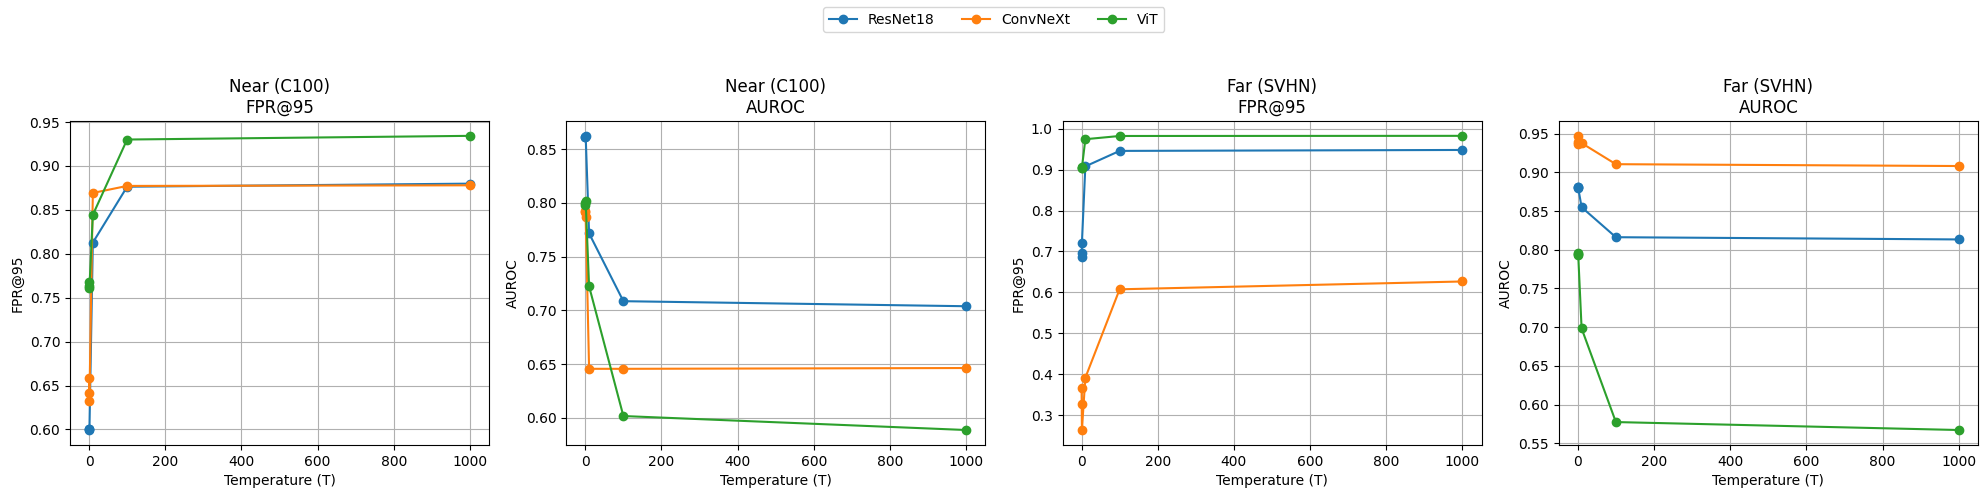

In [31]:
df_energy = df_results[df_results['Metoda'] == 'Energy']
architectures = df_energy['Architektura'].unique()

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)

# --- Near: FPR@95 ---
for arch in architectures:
    sub = df_energy[df_energy['Architektura'] == arch].sort_values('T')
    axes[0].plot(sub['T'], sub['Near (C100) FPR@95'], marker='o', label=arch)

axes[0].set_title('Near (C100)\nFPR@95')
axes[0].set_xlabel('Temperature (T)')
axes[0].set_ylabel('FPR@95')
axes[0].grid(True)

# --- Near: AUROC ---
for arch in architectures:
    sub = df_energy[df_energy['Architektura'] == arch].sort_values('T')
    axes[1].plot(sub['T'], sub['Near (C100) AUROC'], marker='o')

axes[1].set_title('Near (C100)\nAUROC')
axes[1].set_xlabel('Temperature (T)')
axes[1].set_ylabel('AUROC')
axes[1].grid(True)

# --- Far: FPR@95 ---
for arch in architectures:
    sub = df_energy[df_energy['Architektura'] == arch].sort_values('T')
    axes[2].plot(sub['T'], sub['Far (SVHN) FPR@95'], marker='o')

axes[2].set_title('Far (SVHN)\nFPR@95')
axes[2].set_xlabel('Temperature (T)')
axes[2].set_ylabel('FPR@95')
axes[2].grid(True)

# --- Far: AUROC ---
for arch in architectures:
    sub = df_energy[df_energy['Architektura'] == arch].sort_values('T')
    axes[3].plot(sub['T'], sub['Far (SVHN) AUROC'], marker='o')

axes[3].set_title('Far (SVHN)\nAUROC')
axes[3].set_xlabel('Temperature (T)')
axes[3].set_ylabel('AUROC')
axes[3].grid(True)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(architectures))
plt.tight_layout(rect=[0, 0, 1, 0.88])
filename = f"Energy_temperature_plot.png"
plt.savefig(os.path.join(plots_dir, filename), dpi=100)
plt.show()


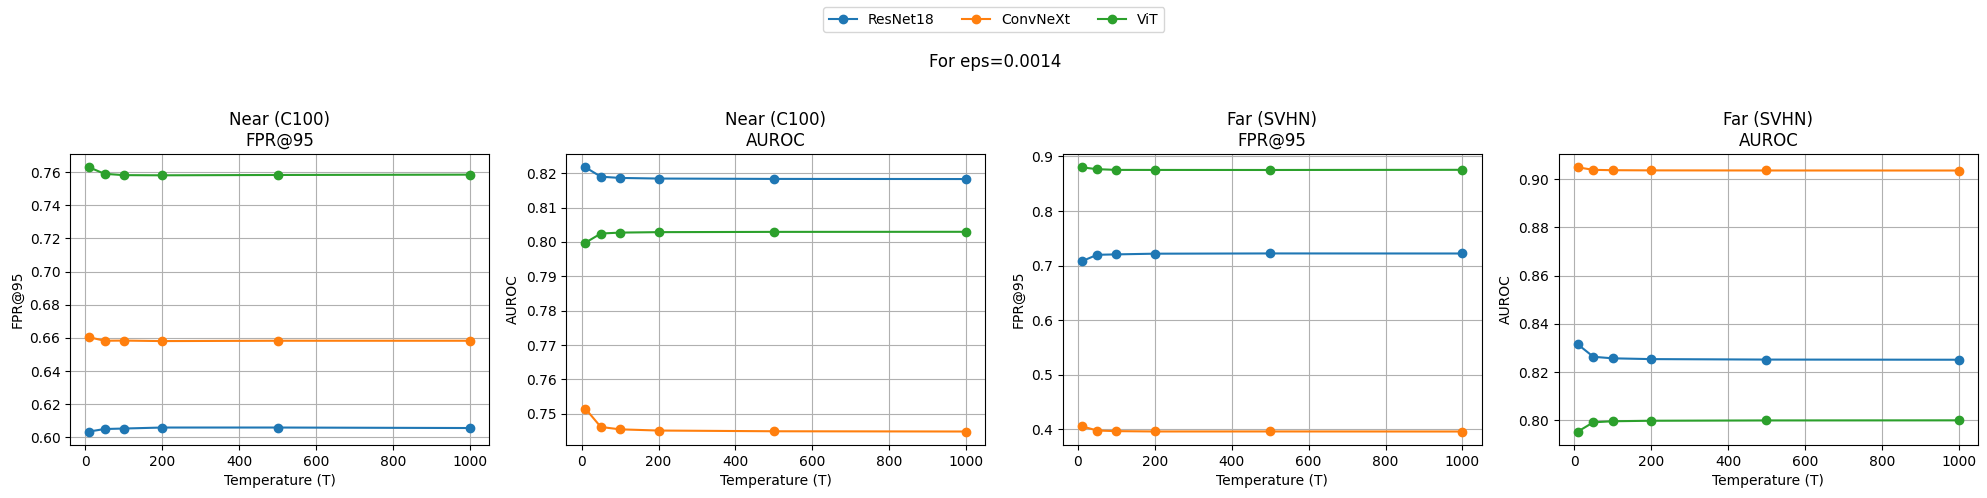

In [32]:
eps_val = 0.0014
df_odin = df_results[df_results['Metoda'] == 'ODIN']
df_odin_eps = df_odin[df_odin['EPS'] == eps_val]
architectures = df_odin_eps['Architektura'].unique()

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
fig.suptitle(f"For eps={eps_val}", y=0.9)

# --- Near: FPR@95 ---
for arch in architectures:
    sub = df_odin_eps[df_odin_eps['Architektura'] == arch].sort_values('T')
    axes[0].plot(sub['T'], sub['Near (C100) FPR@95'], marker='o', label=arch)

axes[0].set_title('Near (C100)\nFPR@95')
axes[0].set_xlabel('Temperature (T)')
axes[0].set_ylabel('FPR@95')
axes[0].grid(True)

# --- Near: AUROC ---
for arch in architectures:
    sub = df_odin_eps[df_odin_eps['Architektura'] == arch].sort_values('T')
    axes[1].plot(sub['T'], sub['Near (C100) AUROC'], marker='o')

axes[1].set_title('Near (C100)\nAUROC')
axes[1].set_xlabel('Temperature (T)')
axes[1].set_ylabel('AUROC')
axes[1].grid(True)

# --- Far: FPR@95 ---
for arch in architectures:
    sub = df_odin_eps[df_odin_eps['Architektura'] == arch].sort_values('T')
    axes[2].plot(sub['T'], sub['Far (SVHN) FPR@95'], marker='o')

axes[2].set_title('Far (SVHN)\nFPR@95')
axes[2].set_xlabel('Temperature (T)')
axes[2].set_ylabel('FPR@95')
axes[2].grid(True)

# --- Far: AUROC ---
for arch in architectures:
    sub = df_odin_eps[df_odin_eps['Architektura'] == arch].sort_values('T')
    axes[3].plot(sub['T'], sub['Far (SVHN) AUROC'], marker='o')

axes[3].set_title('Far (SVHN)\nAUROC')
axes[3].set_xlabel('Temperature (T)')
axes[3].set_ylabel('AUROC')
axes[3].grid(True)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(architectures))
plt.tight_layout(rect=[0, 0, 1, 0.88])
filename = f"ODIN_temperature_plot_eps={eps_val}.png"
plt.savefig(os.path.join(plots_dir, filename), dpi=100)
plt.show()
